<a href="https://colab.research.google.com/github/shelly-serafimovich/target-aware-infrared-sr/blob/main/notebooks/01_thermal_drone_dataset_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermal Drone Dataset — Exploratory Data Analysis

## Purpose

This notebook provides a **dataset-first EDA** for the thermal-drone super-resolution project.

In particular, we want to answer:

1. What is actually contained in the dataset?
2. How are images, annotations, classes, and train/validation/test splits distributed?
3. How small are the targets in the original images?
4. Where do targets tend to appear?
5. What do target and local-background intensity distributions look like?
6. How does downsampling change the effective target size?
7. Which target regimes are likely to be most difficult for super-resolution?
8. Are there dataset biases or split-leakage risks that should be addressed before evaluation?

### Important methodological rule

The **test split must remain an evaluation-only split**.  
Any threshold, noise floor, window size, or other parameter that is learned from data should be selected using the training/validation data only.

## 0. Setup

This notebook expects a Roboflow/YOLOv8 dataset ZIP with the standard structure:

```text
train/images
train/labels
valid/images
valid/labels
test/images
test/labels
data.yaml
```

The uploaded project dataset is version 11 and contains six annotation classes.  
For the current research question, all annotated classes can also be treated as a common **thermal aerial target** category when analyzing target size and location. Class-specific plots are still retained to expose possible source/domain differences.

In [1]:
# Standard-library and scientific Python imports
import os
import re
import math
import hashlib
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import yaml

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Setup complete.")

Setup complete.


### Dataset

In [2]:
# EDIT THIS PATH IF NEEDED.
# In Google Colab, a manually uploaded file usually appears under /content/.
CANDIDATE_ZIPS = [
    Path("/content/thermal-drone.v11i.yolov8.zip"),
    Path("/mnt/data/thermal-drone.v11i.yolov8.zip"),
    Path("thermal-drone.v11i.yolov8.zip"),
]

ZIP_PATH = next((p for p in CANDIDATE_ZIPS if p.exists()), None)

if ZIP_PATH is None:
    raise FileNotFoundError(
        "Dataset ZIP not found. Upload thermal-drone.v11i.yolov8.zip "
        "and update CANDIDATE_ZIPS or ZIP_PATH."
    )

DATASET_DIR = ZIP_PATH.parent / "thermal_drone_v11_yolov8"

if not (DATASET_DIR / "data.yaml").exists():
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATASET_DIR)

print("ZIP:", ZIP_PATH)
print("Dataset directory:", DATASET_DIR)

ZIP: /content/thermal-drone.v11i.yolov8.zip
Dataset directory: /content/thermal_drone_v11_yolov8


## 1. Read Dataset Metadata

First, inspect the declared dataset structure and class names. This is deliberately done before any project-specific filtering.

In [3]:
with open(DATASET_DIR / "data.yaml", "r") as f:
    dataset_yaml = yaml.safe_load(f)

CLASS_NAMES = dataset_yaml["names"]
if isinstance(CLASS_NAMES, dict):
    CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]

print("Number of classes:", dataset_yaml["nc"])
print("Classes:", CLASS_NAMES)
print("\nRaw data.yaml:")
print(dataset_yaml)

Number of classes: 6
Classes: ['0', 'DJI-Phantom', 'DRONE', 'drone-thermal', 'fpv-drone', 'ufo-thermal']

Raw data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 6, 'names': ['0', 'DJI-Phantom', 'DRONE', 'drone-thermal', 'fpv-drone', 'ufo-thermal'], 'roboflow': {'workspace': 'maor-ovadia', 'project': 'thermal-drone-47qfh', 'version': 11, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/maor-ovadia/thermal-drone-47qfh/dataset/11'}}


## 2. Build an Image-Level and Object-Level Metadata Table

YOLO labels use normalized coordinates:

```text
class_id  x_center  y_center  width  height
```

We convert them to pixel units so that target size can be analyzed directly.

In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_rows = []
object_rows = []

for split in ["train", "valid", "test"]:
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    image_paths = sorted([p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])

    for image_path in image_paths:
        with Image.open(image_path) as im:
            W, H = im.size
            mode = im.mode

        label_path = label_dir / f"{image_path.stem}.txt"
        labels = []

        if label_path.exists():
            text = label_path.read_text().strip()
            if text:
                for line in text.splitlines():
                    parts = line.split()
                    if len(parts) >= 5:
                        cls, xc, yc, bw, bh = map(float, parts[:5])
                        labels.append((int(cls), xc, yc, bw, bh))

        image_rows.append({
            "split": split,
            "image_path": str(image_path),
            "label_path": str(label_path),
            "filename": image_path.name,
            "width_px": W,
            "height_px": H,
            "image_area_px": W * H,
            "mode": mode,
            "n_objects": len(labels),
            "has_target": len(labels) > 0,
        })

        for obj_idx, (cls, xc, yc, bw, bh) in enumerate(labels):
            w_px = bw * W
            h_px = bh * H
            x_px = xc * W
            y_px = yc * H

            object_rows.append({
                "split": split,
                "image_path": str(image_path),
                "filename": image_path.name,
                "object_idx": obj_idx,
                "class_id": cls,
                "class_name": CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls),
                "image_width_px": W,
                "image_height_px": H,
                "x_center_norm": xc,
                "y_center_norm": yc,
                "bbox_width_norm": bw,
                "bbox_height_norm": bh,
                "bbox_width_px": w_px,
                "bbox_height_px": h_px,
                "bbox_area_px": w_px * h_px,
                "bbox_area_fraction": bw * bh,
                "bbox_diagonal_px": np.hypot(w_px, h_px),
                "aspect_ratio": w_px / max(h_px, 1e-9),
            })

images_df = pd.DataFrame(image_rows)
objects_df = pd.DataFrame(object_rows)

print("Images:", len(images_df))
print("Annotated objects:", len(objects_df))
display(images_df.head())
display(objects_df.head())

Images: 7032
Annotated objects: 6110


,split,image_path,label_path,filename,width_px,height_px,image_area_px,mode,n_objects,has_target
0,train,/content/thermal_drone_v11_yolov8/train/images...,/content/thermal_drone_v11_yolov8/train/labels...,000001_jpg.rf.1e5ba0d226980274d2081920228b74cb...,640,640,409600,RGB,1,True
1,train,/content/thermal_drone_v11_yolov8/train/images...,/content/thermal_drone_v11_yolov8/train/labels...,000001_jpg.rf.72b2188fa42e2a730d0f8d9310dd9bc3...,640,640,409600,RGB,1,True
2,train,/content/thermal_drone_v11_yolov8/train/images...,/content/thermal_drone_v11_yolov8/train/labels...,000001_jpg.rf.bfa5b7a49a428920acea0bf83e962a04...,640,640,409600,RGB,1,True
3,train,/content/thermal_drone_v11_yolov8/train/images...,/content/thermal_drone_v11_yolov8/train/labels...,000001_jpg.rf.f997a8624743f37b543dd80c9613d4b2...,640,640,409600,RGB,1,True
4,train,/content/thermal_drone_v11_yolov8/train/images...,/content/thermal_drone_v11_yolov8/train/labels...,000002_jpg.rf.26ea1e28fca6dc0a578561951d1fbfd1...,640,640,409600,RGB,1,True


,split,image_path,filename,object_idx,class_id,class_name,image_width_px,image_height_px,x_center_norm,y_center_norm,bbox_width_norm,bbox_height_norm,bbox_width_px,bbox_height_px,bbox_area_px,bbox_area_fraction,bbox_diagonal_px,aspect_ratio
0,train,/content/thermal_drone_v11_yolov8/train/images...,000001_jpg.rf.1e5ba0d226980274d2081920228b74cb...,0,2,DRONE,640,640,0.589063,0.514844,0.181250,0.107813,116.0,69.0,8004.0,0.019541,134.970367,1.681159
1,train,/content/thermal_drone_v11_yolov8/train/images...,000001_jpg.rf.72b2188fa42e2a730d0f8d9310dd9bc3...,0,2,DRONE,640,640,0.427344,0.147656,0.098437,0.042188,63.0,27.0,1701.0,0.004153,68.541958,2.333333
2,train,/content/thermal_drone_v11_yolov8/train/images...,000001_jpg.rf.bfa5b7a49a428920acea0bf83e962a04...,0,2,DRONE,640,640,0.425781,0.149219,0.098437,0.042188,63.0,27.0,1701.0,0.004153,68.541958,2.333333
3,train,/content/thermal_drone_v11_yolov8/train/images...,000001_jpg.rf.f997a8624743f37b543dd80c9613d4b2...,0,2,DRONE,640,640,0.587500,0.491406,0.181250,0.117188,116.0,75.0,8700.0,0.021240,138.133993,1.546667
4,train,/content/thermal_drone_v11_yolov8/train/images...,000002_jpg.rf.26ea1e28fca6dc0a578561951d1fbfd1...,0,2,DRONE,640,640,0.428125,0.147656,0.109375,0.045312,70.0,29.0,2030.0,0.004956,75.769387,2.413793


## 3. Dataset Inventory and Split Balance

Questions:

- How many images are in each split?
- How many annotated targets are in each split?
- How many images contain no annotation?
- Are the positive/negative ratios similar across splits?

A large imbalance between splits can distort evaluation.

In [5]:
split_summary = (
    images_df.groupby("split")
    .agg(
        n_images=("filename", "count"),
        positive_images=("has_target", "sum"),
        empty_images=("has_target", lambda x: (~x).sum()),
        mean_objects_per_image=("n_objects", "mean"),
        median_objects_per_image=("n_objects", "median"),
    )
)

objects_per_split = objects_df.groupby("split").size().rename("n_objects")
split_summary = split_summary.join(objects_per_split)
split_summary["positive_image_rate"] = (
    split_summary["positive_images"] / split_summary["n_images"]
)

display(split_summary.round(3))

,n_images,positive_images,empty_images,mean_objects_per_image,median_objects_per_image,n_objects,positive_image_rate
split,,,,,,,
test,2108,1816,292,0.861,1.0,1816,0.861
train,2809,2471,338,0.881,1.0,2474,0.880
valid,2115,1819,296,0.861,1.0,1820,0.860


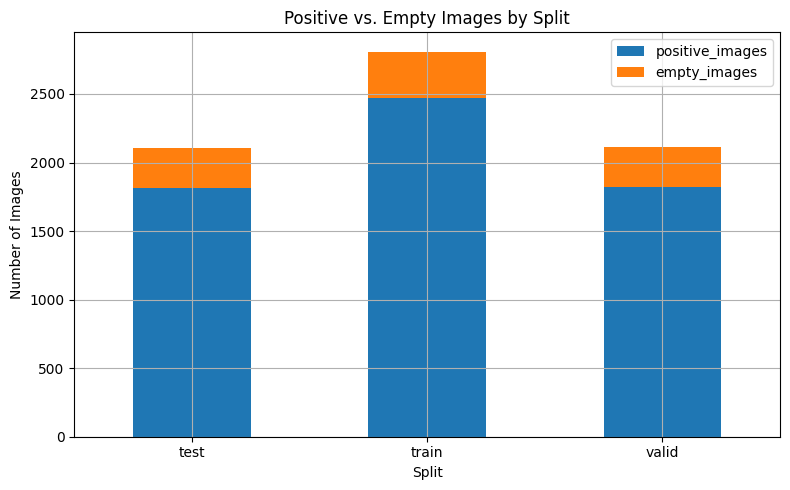

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
summary_plot = split_summary[["positive_images", "empty_images"]]
summary_plot.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Positive vs. Empty Images by Split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Image Resolution and Format

Mixed image resolutions can strongly affect the interpretation of target size in pixels.  
We therefore inspect image dimensions before analyzing bounding boxes.

,width_px,height_px,count
0,640,512,6436
1,640,640,591
2,1920,1080,5


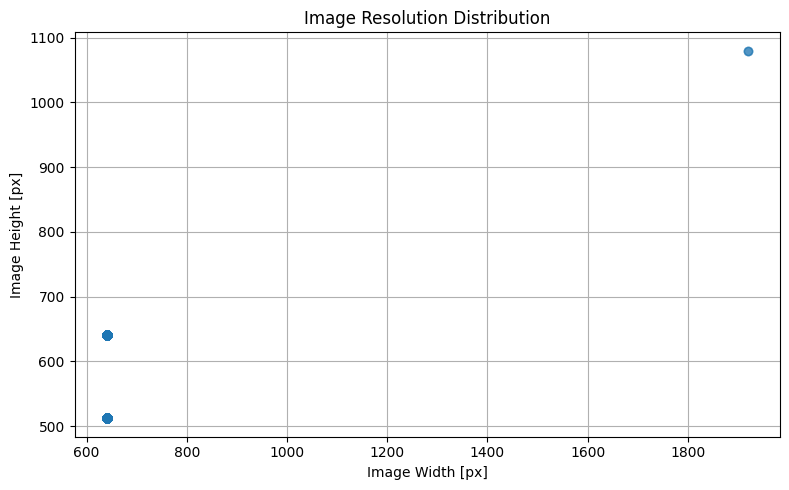

In [7]:
resolution_counts = (
    images_df.groupby(["width_px", "height_px"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(resolution_counts.head(20))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(images_df["width_px"], images_df["height_px"], alpha=0.25)
ax.set_title("Image Resolution Distribution")
ax.set_xlabel("Image Width [px]")
ax.set_ylabel("Image Height [px]")
plt.tight_layout()
plt.show()

## 5. Class Distribution

Even if all classes are ultimately treated as "drone/thermal aerial target", class imbalance may reveal different acquisition sources or annotation conventions.

class_name,0,DJI-Phantom,DRONE,drone-thermal,fpv-drone,ufo-thermal
split,,,,,,
test,943,139,361,22,343,8
train,1146,232,575,27,484,10
valid,922,134,232,15,507,10


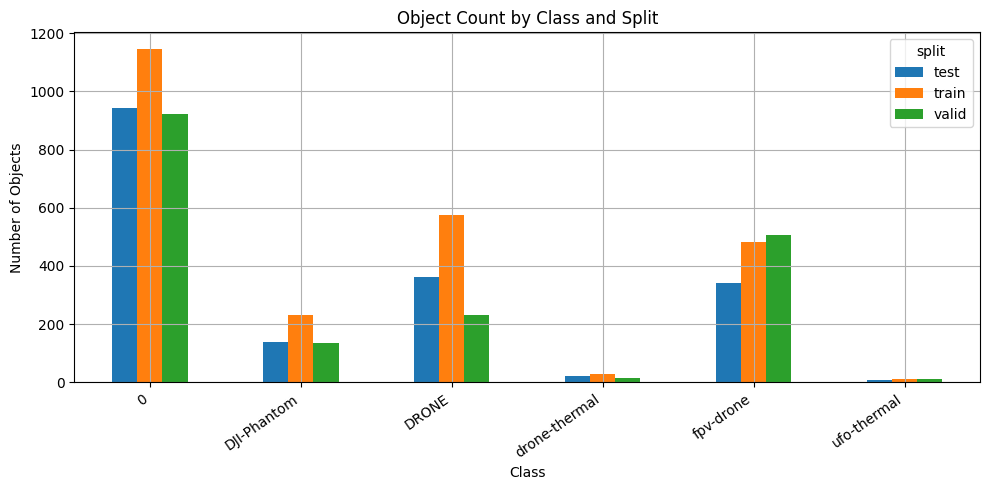

In [8]:
class_counts = (
    objects_df.groupby(["split", "class_name"])
    .size()
    .unstack(fill_value=0)
)

display(class_counts)

class_counts.T.plot(kind="bar", figsize=(10, 5))
plt.title("Object Count by Class and Split")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 6. Number of Targets per Image

This matters for patch extraction and later evaluation. Images with many objects should not accidentally dominate object-level statistics.

,n_objects
count,7032.000000
mean,0.868885
std,0.339231
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


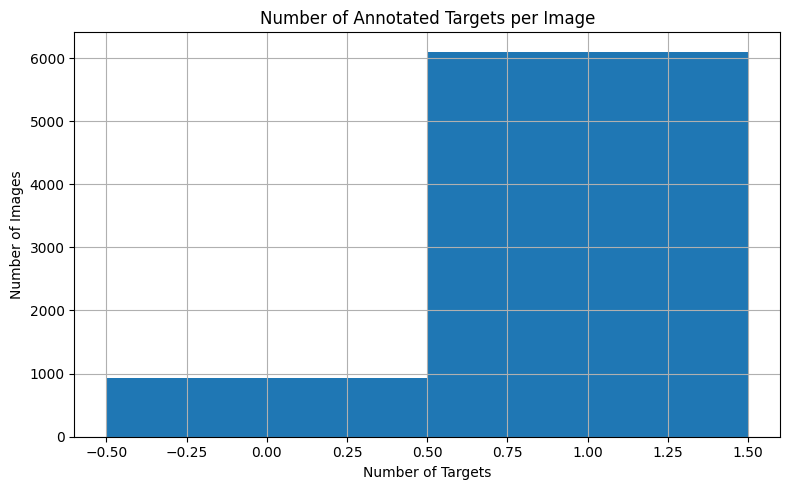

In [9]:
display(images_df["n_objects"].describe())

max_count = int(images_df["n_objects"].quantile(0.99))
bins = np.arange(0, max(max_count + 2, 3)) - 0.5

plt.figure(figsize=(8, 5))
plt.hist(images_df["n_objects"], bins=bins)
plt.title("Number of Annotated Targets per Image")
plt.xlabel("Number of Targets")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# 7. Target Size Analysis

This is one of the most important sections for the project.

We examine:

- bounding-box width and height,
- area in pixels,
- diagonal length,
- fraction of the full image occupied by the target,
- aspect ratio.

For a tiny-target SR project, **pixel size after degradation** is ultimately more important than HR size alone.

In [10]:
size_cols = [
    "bbox_width_px", "bbox_height_px", "bbox_area_px",
    "bbox_diagonal_px", "bbox_area_fraction", "aspect_ratio"
]
display(objects_df[size_cols].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]).T)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
bbox_width_px,6110.0,1.195082e+02,1.619806e+02,0.570000,4.000000,5.000000,6.000000,13.000000,48.000000,151.000000,423.100000,480.000000,581.000000,6.390000e+02
bbox_height_px,6110.0,6.968565e+01,9.847431e+01,0.000000,5.000000,6.000000,7.000000,10.000000,23.000000,84.000000,231.100000,261.000000,455.000000,4.930000e+02
bbox_area_px,6110.0,2.162794e+04,4.375962e+04,0.000000,20.000000,30.000000,40.000000,110.000000,950.000000,9215.000000,86443.000000,105887.350000,208110.100000,2.682590e+05
bbox_diagonal_px,6110.0,1.411620e+02,1.874736e+02,0.799062,6.708204,7.810250,9.219544,15.652476,53.600256,159.380049,477.245323,536.580469,675.578677,7.439207e+02
bbox_area_fraction,6110.0,6.581184e-02,1.336225e-01,0.000000,0.000061,0.000092,0.000122,0.000336,0.002865,0.028122,0.263803,0.323143,0.635102,8.186615e-01
aspect_ratio,6110.0,5.122750e+07,4.004273e+09,0.162162,0.600000,0.750000,0.833333,1.000000,1.449219,1.991379,2.875000,3.250000,4.885918,3.130000e+11


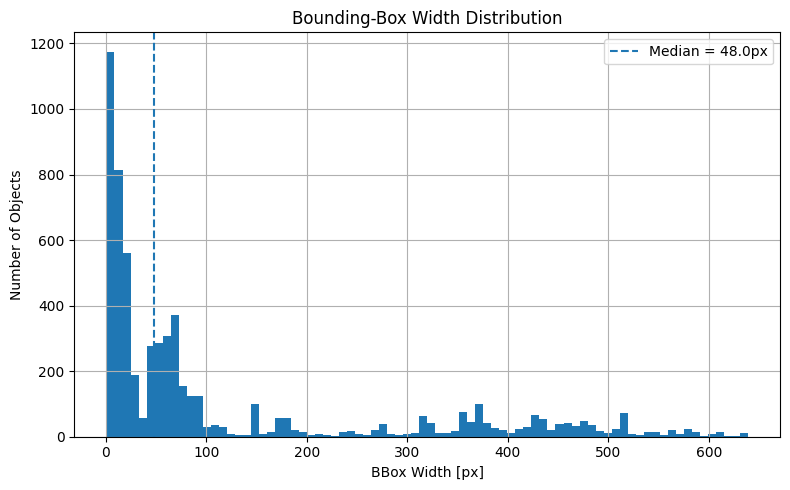

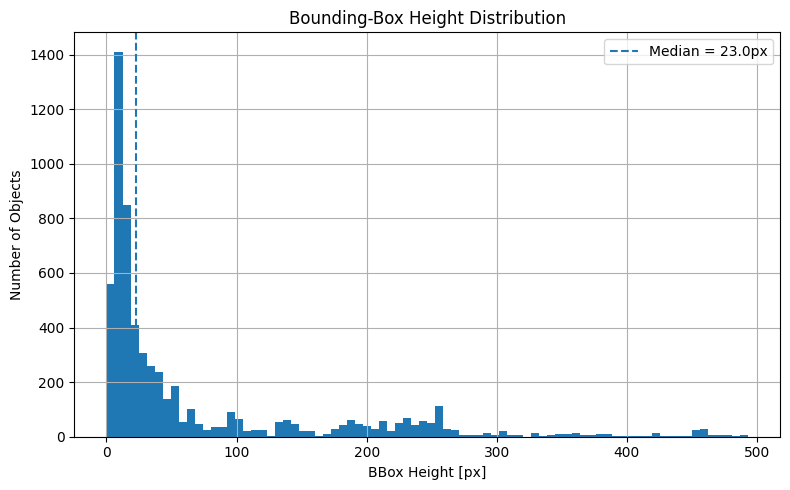

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(objects_df["bbox_width_px"], bins=80)
ax.axvline(objects_df["bbox_width_px"].median(), linestyle="--",
           label=f"Median = {objects_df['bbox_width_px'].median():.1f}px")
ax.set_title("Bounding-Box Width Distribution")
ax.set_xlabel("BBox Width [px]")
ax.set_ylabel("Number of Objects")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(objects_df["bbox_height_px"], bins=80)
ax.axvline(objects_df["bbox_height_px"].median(), linestyle="--",
           label=f"Median = {objects_df['bbox_height_px'].median():.1f}px")
ax.set_title("Bounding-Box Height Distribution")
ax.set_xlabel("BBox Height [px]")
ax.set_ylabel("Number of Objects")
ax.legend()
plt.tight_layout()
plt.show()

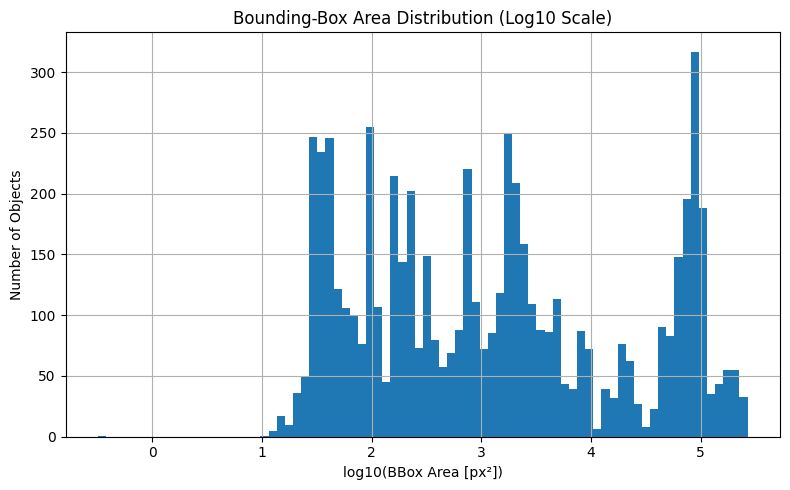

In [12]:
# Log scale is useful because target area is often highly right-skewed.
positive_area = objects_df.loc[objects_df["bbox_area_px"] > 0, "bbox_area_px"]

plt.figure(figsize=(8, 5))
plt.hist(np.log10(positive_area), bins=80)
plt.title("Bounding-Box Area Distribution (Log10 Scale)")
plt.xlabel("log10(BBox Area [px²])")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

### Size stratification

Rather than using a single median target size, we explicitly divide the dataset into size regimes.

The bins below are initially defined from **LR effective size** later in the notebook.  
For HR exploration, quantile-based groups are also useful because they avoid arbitrary thresholds.

In [13]:
objects_df["hr_size_quantile"] = pd.qcut(
    objects_df["bbox_area_px"],
    q=4,
    labels=["Q1: smallest", "Q2", "Q3", "Q4: largest"],
    duplicates="drop"
)

display(
    objects_df.groupby("hr_size_quantile", observed=True)["bbox_area_px"]
    .agg(["count", "min", "median", "max"])
)

,count,min,median,max
hr_size_quantile,,,,
Q1: smallest,1549,0.0,42.0,110.0
Q2,1509,112.0,304.0,950.0
Q3,1529,952.0,2310.0,9215.0
Q4: largest,1523,9348.0,78369.0,268259.0


## 8. Target Location Bias

A heatmap of normalized target centers reveals whether targets are disproportionately concentrated in the center, top, horizon region, or another part of the frame.

This matters because a model can exploit dataset bias instead of learning a physically meaningful target prior.

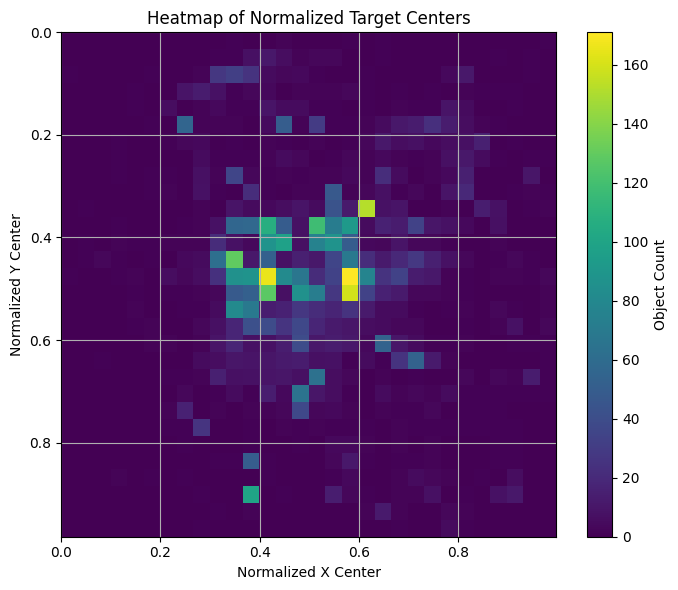

In [14]:
plt.figure(figsize=(7, 6))
plt.hist2d(
    objects_df["x_center_norm"],
    objects_df["y_center_norm"],
    bins=30
)
plt.gca().invert_yaxis()
plt.colorbar(label="Object Count")
plt.title("Heatmap of Normalized Target Centers")
plt.xlabel("Normalized X Center")
plt.ylabel("Normalized Y Center")
plt.tight_layout()
plt.show()

## 9. Visual Annotation Sanity Check

Before trusting any statistic, inspect random examples with their bounding boxes.

This catches:

- incorrect labels,
- unexpected object classes,
- boxes that include excessive background,
- annotation convention differences,
- images that are not actually thermal,
- very large targets that may be irrelevant to the tiny-target research question.

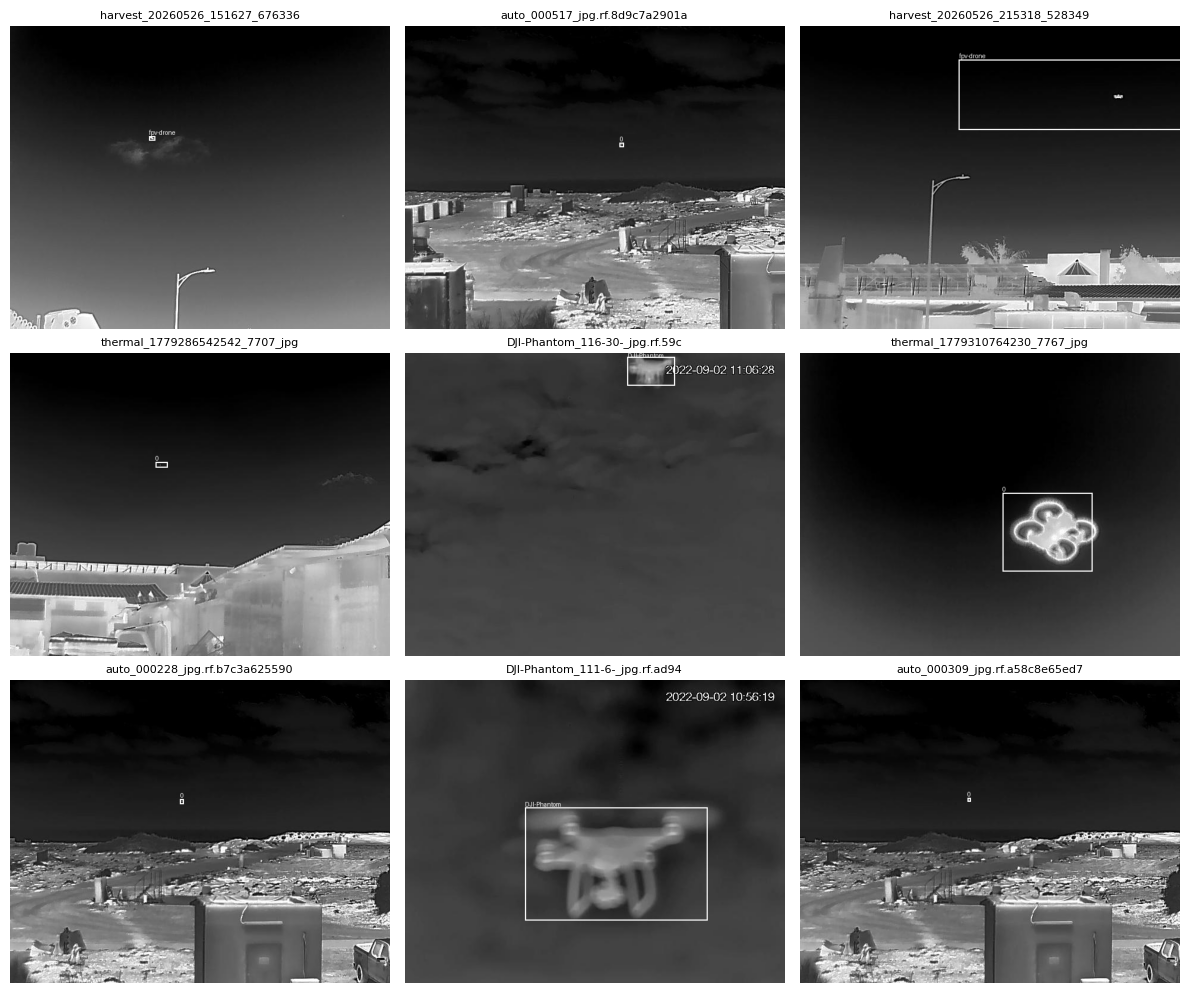

In [15]:
def draw_yolo_boxes(image_path, rows):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    W, H = image.size

    for _, row in rows.iterrows():
        xc = row["x_center_norm"] * W
        yc = row["y_center_norm"] * H
        bw = row["bbox_width_norm"] * W
        bh = row["bbox_height_norm"] * H

        x1, y1 = xc - bw/2, yc - bh/2
        x2, y2 = xc + bw/2, yc + bh/2

        draw.rectangle([x1, y1, x2, y2], width=2)
        draw.text((x1, max(0, y1 - 12)), row["class_name"])

    return image

rng = np.random.default_rng(42)
sample_paths = rng.choice(
    images_df.loc[images_df["has_target"], "image_path"].values,
    size=min(9, images_df["has_target"].sum()),
    replace=False
)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = np.array(axes).ravel()

for ax, image_path in zip(axes, sample_paths):
    rows = objects_df[objects_df["image_path"] == image_path]
    image = draw_yolo_boxes(image_path, rows)
    ax.imshow(image)
    ax.set_title(Path(image_path).name[:30], fontsize=8)
    ax.axis("off")

for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# 10. Pixel Intensity Characterization

The project assumes that small thermal targets behave differently from their local background.

Before using SCR/Hoyer, we first inspect simpler quantities:

- target mean intensity,
- target maximum intensity,
- local-ring mean intensity,
- local-ring standard deviation,
- target-minus-background contrast.

### Important limitation

These JPG images contain **display/intensity values**, not calibrated radiometric temperature.  
Therefore, this analysis describes the dataset's image intensities, not physical temperature in degrees.

In [16]:
def read_gray(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)

def bbox_and_ring_stats(row, ring_scale=2.0):
    img = read_gray(row["image_path"])
    H, W = img.shape

    xc = row["x_center_norm"] * W
    yc = row["y_center_norm"] * H
    bw = max(row["bbox_width_norm"] * W, 1)
    bh = max(row["bbox_height_norm"] * H, 1)

    x1 = max(0, int(np.floor(xc - bw/2)))
    x2 = min(W, int(np.ceil(xc + bw/2)))
    y1 = max(0, int(np.floor(yc - bh/2)))
    y2 = min(H, int(np.ceil(yc + bh/2)))

    rx1 = max(0, int(np.floor(xc - ring_scale*bw/2)))
    rx2 = min(W, int(np.ceil(xc + ring_scale*bw/2)))
    ry1 = max(0, int(np.floor(yc - ring_scale*bh/2)))
    ry2 = min(H, int(np.ceil(yc + ring_scale*bh/2)))

    target = img[y1:y2, x1:x2]
    outer = img[ry1:ry2, rx1:rx2]

    if target.size == 0 or outer.size == 0:
        return None

    mask = np.ones_like(outer, dtype=bool)
    tx1, tx2 = x1-rx1, x2-rx1
    ty1, ty2 = y1-ry1, y2-ry1
    mask[ty1:ty2, tx1:tx2] = False
    ring = outer[mask]

    if ring.size == 0:
        return None

    return {
        "target_mean": float(target.mean()),
        "target_max": float(target.max()),
        "target_std": float(target.std()),
        "ring_mean": float(ring.mean()),
        "ring_std": float(ring.std()),
        "mean_contrast": float(target.mean() - ring.mean()),
        "peak_contrast": float(target.max() - ring.mean()),
        "simple_peak_scr": float((target.max() - ring.mean()) / (ring.std() + 1e-6)),
    }

# Use a deterministic subset for speed.
# Increase MAX_OBJECTS if you want a full-dataset analysis.
MAX_OBJECTS = min(3000, len(objects_df))
sample_for_intensity = objects_df.sample(MAX_OBJECTS, random_state=42)

intensity_records = []
for idx, row in sample_for_intensity.iterrows():
    stats = bbox_and_ring_stats(row)
    if stats is not None:
        intensity_records.append({"object_index": idx, **stats})

intensity_df = pd.DataFrame(intensity_records).set_index("object_index")
objects_with_intensity = sample_for_intensity.join(intensity_df, how="inner")

display(objects_with_intensity[
    ["target_mean", "target_max", "ring_mean", "ring_std",
     "mean_contrast", "peak_contrast", "simple_peak_scr"]
].describe().T)

,count,mean,std,min,25%,50%,75%,max
target_mean,3000.0,64.773140,41.086551,0.671404,35.380207,51.862553,89.184015,221.634216
target_max,3000.0,200.014667,68.603342,28.000000,122.000000,254.000000,255.000000,255.000000
ring_mean,3000.0,44.321192,32.034482,0.034286,24.821223,36.589939,57.813768,211.305084
ring_std,3000.0,15.557511,18.496293,0.449571,3.045846,6.417476,19.912824,78.374451
mean_contrast,3000.0,20.451948,27.720919,-66.855385,0.552628,10.534627,38.502114,140.316284
peak_contrast,3000.0,155.693474,64.602939,0.302084,90.239607,179.220444,208.282856,254.910568
simple_peak_scr,3000.0,31.357189,49.872846,0.310640,8.209020,20.642910,38.789980,567.007446


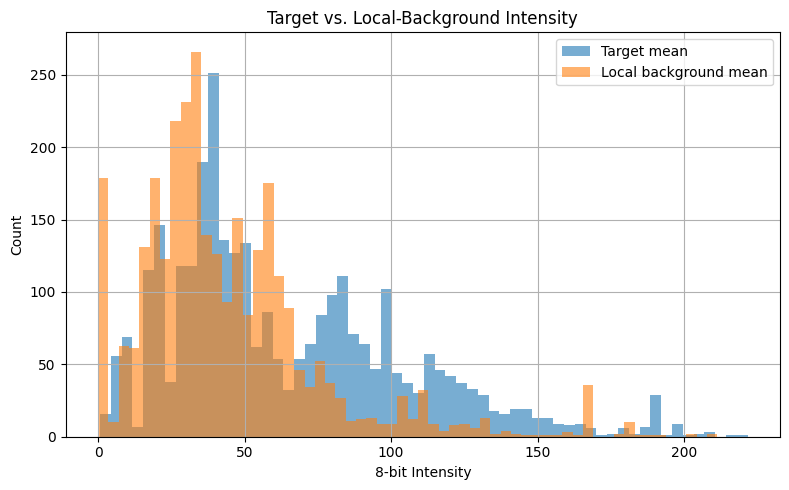

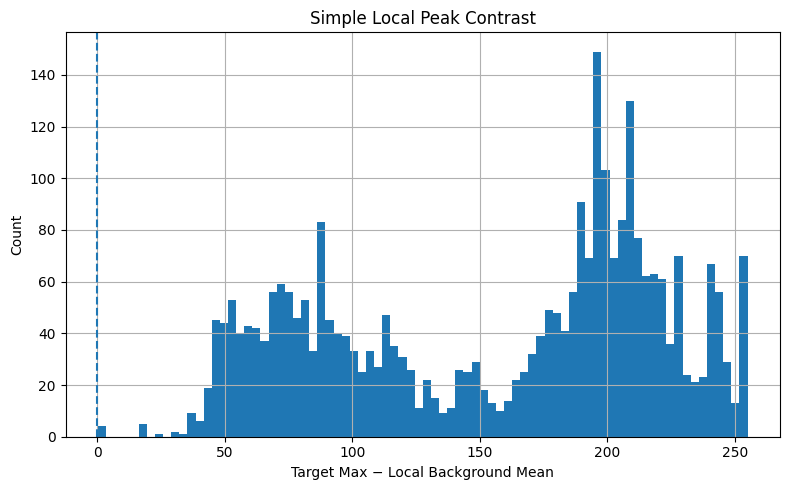

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(objects_with_intensity["target_mean"], bins=60, alpha=0.6, label="Target mean")
plt.hist(objects_with_intensity["ring_mean"], bins=60, alpha=0.6, label="Local background mean")
plt.title("Target vs. Local-Background Intensity")
plt.xlabel("8-bit Intensity")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(objects_with_intensity["peak_contrast"], bins=80)
plt.axvline(0, linestyle="--")
plt.title("Simple Local Peak Contrast")
plt.xlabel("Target Max − Local Background Mean")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Check the "hotter than local background" assumption

A positive value means the brightest target pixel is above the local-background mean.  
This is a basic empirical check of a key physical assumption behind positive-residual guidance.

In [18]:
hotter_fraction = (objects_with_intensity["peak_contrast"] > 0).mean()
mean_hotter_fraction = (objects_with_intensity["mean_contrast"] > 0).mean()

print(f"Fraction with target MAX above local-background mean: {hotter_fraction:.3%}")
print(f"Fraction with target MEAN above local-background mean: {mean_hotter_fraction:.3%}")

Fraction with target MAX above local-background mean: 100.000%
Fraction with target MEAN above local-background mean: 79.533%


# 11. Simulated Low-Resolution Degradation

The SR system does not receive the HR image at inference time.  
Therefore, the most relevant target size is the target's **effective size in LR**.

Set `SCALE_FACTOR` to the same scale factor used by the DifIISR experiment.

In [19]:
# IMPORTANT: Set this to the exact SR scale used in the DifIISR pipeline.
SCALE_FACTOR = 4

objects_df["lr_bbox_width_px"] = objects_df["bbox_width_px"] / SCALE_FACTOR
objects_df["lr_bbox_height_px"] = objects_df["bbox_height_px"] / SCALE_FACTOR
objects_df["lr_bbox_area_px"] = objects_df["bbox_area_px"] / (SCALE_FACTOR ** 2)
objects_df["lr_bbox_diagonal_px"] = objects_df["bbox_diagonal_px"] / SCALE_FACTOR

display(
    objects_df[
        ["lr_bbox_width_px", "lr_bbox_height_px",
         "lr_bbox_area_px", "lr_bbox_diagonal_px"]
    ].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]).T
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
lr_bbox_width_px,6110.0,29.877041,40.495149,0.142500,1.000000,1.250000,1.500000,3.250000,12.000000,37.750000,105.775000,120.000000,145.250000,159.750000
lr_bbox_height_px,6110.0,17.421412,24.618577,0.000000,1.250000,1.500000,1.750000,2.500000,5.750000,21.000000,57.775000,65.250000,113.750000,123.250000
lr_bbox_area_px,6110.0,1351.746222,2734.976526,0.000000,1.250000,1.875000,2.500000,6.875000,59.375000,575.937500,5402.687500,6617.959375,13006.881250,16766.187500
lr_bbox_diagonal_px,6110.0,35.290495,46.868406,0.199765,1.677051,1.952562,2.304886,3.913119,13.400064,39.845012,119.311331,134.145117,168.894669,185.980174


,n_objects,fraction
lr_size_regime,,
≤2 px,1073,0.175614
2–4 px,907,0.148445
4–8 px,751,0.122913
8–16 px,930,0.152209
>16 px,2449,0.400818


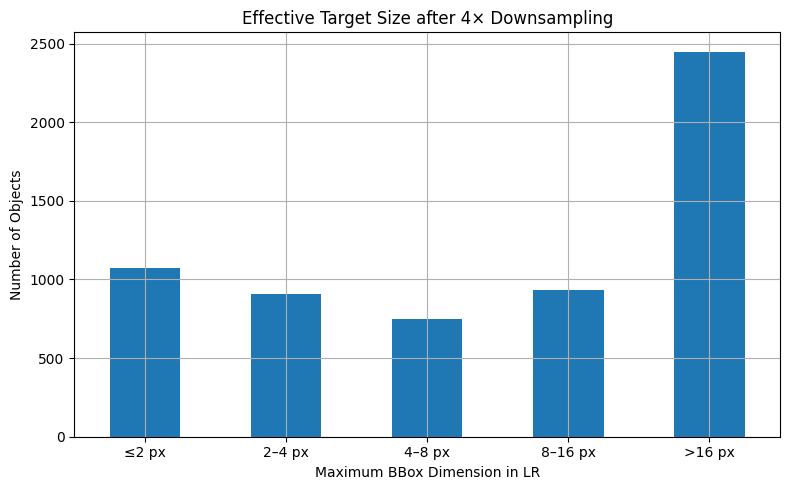

In [20]:
# Categorize by the larger LR dimension.
# These bins are descriptive and can be changed; they are not learned model thresholds.
objects_df["lr_max_dim_px"] = objects_df[
    ["lr_bbox_width_px", "lr_bbox_height_px"]
].max(axis=1)

objects_df["lr_size_regime"] = pd.cut(
    objects_df["lr_max_dim_px"],
    bins=[0, 2, 4, 8, 16, np.inf],
    labels=["≤2 px", "2–4 px", "4–8 px", "8–16 px", ">16 px"],
    include_lowest=True
)

lr_size_table = (
    objects_df["lr_size_regime"]
    .value_counts(sort=False)
    .rename("n_objects")
    .to_frame()
)
lr_size_table["fraction"] = lr_size_table["n_objects"] / len(objects_df)

display(lr_size_table)

plt.figure(figsize=(8, 5))
lr_size_table["n_objects"].plot(kind="bar")
plt.title(f"Effective Target Size after {SCALE_FACTOR}× Downsampling")
plt.xlabel("Maximum BBox Dimension in LR")
plt.ylabel("Number of Objects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. Visualize the Effect of LR Degradation

This section shows HR, downsampled LR, and nearest-neighbor enlarged LR side-by-side.

The purpose is not to evaluate SR yet. It is to understand how much target information remains available to the SR model.

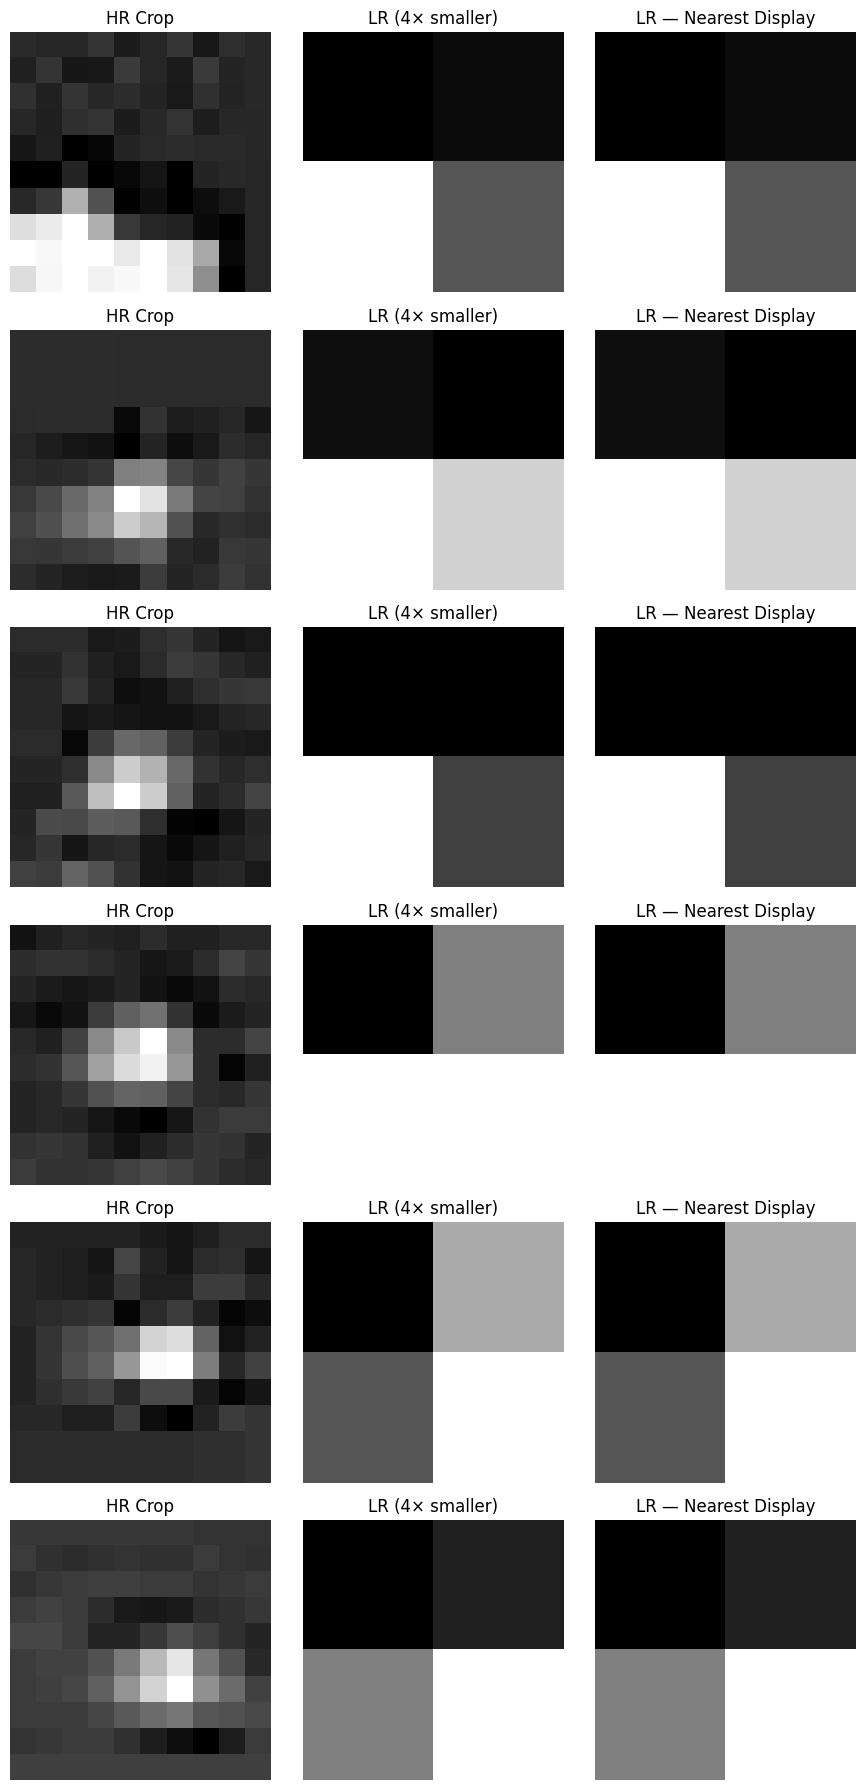

In [21]:
def crop_around_bbox(row, padding=2.5):
    img = Image.open(row["image_path"]).convert("L")
    W, H = img.size

    xc = row["x_center_norm"] * W
    yc = row["y_center_norm"] * H
    bw = max(row["bbox_width_norm"] * W, 4)
    bh = max(row["bbox_height_norm"] * H, 4)

    half = max(bw, bh) * padding / 2
    x1 = max(0, int(xc - half))
    y1 = max(0, int(yc - half))
    x2 = min(W, int(xc + half))
    y2 = min(H, int(yc + half))

    return img.crop((x1, y1, x2, y2))

tiny_examples = objects_df.sort_values("lr_max_dim_px").head(6)

fig, axes = plt.subplots(len(tiny_examples), 3, figsize=(9, 3 * len(tiny_examples)))

for row_i, (_, row) in enumerate(tiny_examples.iterrows()):
    hr_crop = crop_around_bbox(row)
    lr_size = (
        max(1, hr_crop.width // SCALE_FACTOR),
        max(1, hr_crop.height // SCALE_FACTOR),
    )
    lr = hr_crop.resize(lr_size, Image.Resampling.BICUBIC)
    lr_display = lr.resize(hr_crop.size, Image.Resampling.NEAREST)

    axes[row_i, 0].imshow(hr_crop, cmap="gray")
    axes[row_i, 0].set_title("HR Crop")

    axes[row_i, 1].imshow(lr, cmap="gray")
    axes[row_i, 1].set_title(f"LR ({SCALE_FACTOR}× smaller)")

    axes[row_i, 2].imshow(lr_display, cmap="gray")
    axes[row_i, 2].set_title("LR — Nearest Display")

    for ax in axes[row_i]:
        ax.axis("off")

plt.tight_layout()
plt.show()

# 13. Size vs. Local Contrast

This plot tests whether the hardest targets are simultaneously:

- spatially tiny, and
- weakly separated from their local background.

That region is particularly relevant for the proposed target-preserving guidance.

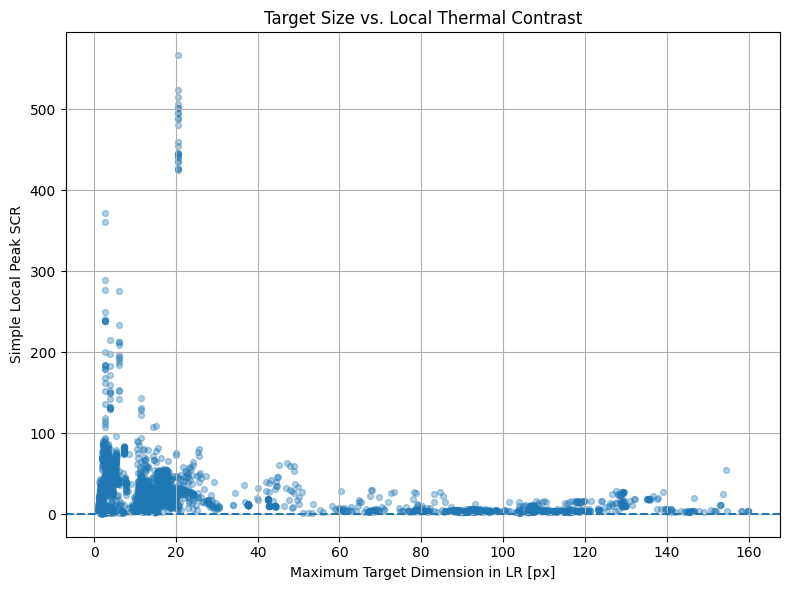

In [22]:
analysis_df = objects_with_intensity.join(
    objects_df[["lr_max_dim_px", "lr_bbox_area_px"]],
    how="left",
    rsuffix="_all"
)

plt.figure(figsize=(8, 6))
plt.scatter(
    analysis_df["lr_max_dim_px"],
    analysis_df["simple_peak_scr"],
    alpha=0.35,
    s=18
)
plt.xlabel("Maximum Target Dimension in LR [px]")
plt.ylabel("Simple Local Peak SCR")
plt.title("Target Size vs. Local Thermal Contrast")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

# 14. Check for Potential Split Leakage

Thermal-drone datasets are often created from video frames. Randomly splitting adjacent frames can make train and test images nearly identical.

This is a serious concern for scientific evaluation.

We perform two checks:

1. **Exact file-content duplicates** using hashes.
2. **Source-name grouping** by removing the Roboflow augmentation/hash suffix.

The second check is only a heuristic, but it can expose obvious sequence overlap.

In [23]:
def sha1_file(path, chunk_size=1 << 20):
    h = hashlib.sha1()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

# Exact duplicates
hash_rows = []
for _, row in images_df.iterrows():
    hash_rows.append({
        "split": row["split"],
        "filename": row["filename"],
        "image_path": row["image_path"],
        "sha1": sha1_file(row["image_path"])
    })

hash_df = pd.DataFrame(hash_rows)
dup_hashes = (
    hash_df.groupby("sha1")
    .filter(lambda g: g["split"].nunique() > 1)
    .sort_values("sha1")
)

print("Exact cross-split duplicate images:", len(dup_hashes))
display(dup_hashes.head(20))

Exact cross-split duplicate images: 0


,split,filename,image_path,sha1


In [24]:
def roboflow_source_stem(filename):
    stem = Path(filename).stem
    # Roboflow exported names commonly end with: _jpg.rf.<hash>
    stem = re.sub(r"_jpg\.rf\.[A-Za-z0-9]+$", "", stem)
    stem = re.sub(r"\.rf\.[A-Za-z0-9]+$", "", stem)
    return stem

source_df = images_df[["split", "filename"]].copy()
source_df["source_stem"] = source_df["filename"].map(roboflow_source_stem)

cross_split_sources = (
    source_df.groupby("source_stem")
    .filter(lambda g: g["split"].nunique() > 1)
    .sort_values("source_stem")
)

print("Potential source-name overlap rows:", len(cross_split_sources))
display(cross_split_sources.head(30))

Potential source-name overlap rows: 536


,split,filename,source_stem
0,train,000001_jpg.rf.1e5ba0d226980274d2081920228b74cb...,000001
4924,test,000001_jpg.rf.abca72b52270031ec58a2715b140d26f...,000001
3,train,000001_jpg.rf.f997a8624743f37b543dd80c9613d4b2...,000001
2809,valid,000001_jpg.rf.04ff62c073f8b627cde0ee82b4f7571b...,000001
2,train,000001_jpg.rf.bfa5b7a49a428920acea0bf83e962a04...,000001
1,train,000001_jpg.rf.72b2188fa42e2a730d0f8d9310dd9bc3...,000001
4,train,000002_jpg.rf.26ea1e28fca6dc0a578561951d1fbfd1...,000002
2810,valid,000002_jpg.rf.b7cdcc6d39743d7912f4e8e2924535ab...,000002
4925,test,000002_jpg.rf.85c329efe52613afb92f55d4058767f1...,000002
2811,valid,000002_jpg.rf.c8f1303f3388711931fb8d2389c8261f...,000002


## 15. Optional: Consecutive-Frame / Sequence Bias

The filenames suggest that part of the dataset may originate from recorded sequences (`auto_*`, `thermal_*`, `harvest_*`, etc.).

For a publication-quality experiment, the preferred split is usually **sequence-aware** rather than frame-random:

- all frames from one original sequence should belong to one split only;
- train/validation/test should not contain near-adjacent frames from the same recording.

The exact sequence identity cannot always be recovered from exported filenames, so this section reports filename families as a first diagnostic rather than claiming definitive leakage.

In [25]:
def filename_family(filename):
    s = roboflow_source_stem(filename)
    # Keep a coarse prefix before the first long numeric run.
    s = re.sub(r"\d{4,}.*$", "", s)
    s = s.rstrip("_-")
    return s if s else "other"

family_table = (
    images_df.assign(family=images_df["filename"].map(filename_family))
    .groupby(["family", "split"])
    .size()
    .unstack(fill_value=0)
    .sort_values("train", ascending=False)
)

display(family_table.head(30))

split,test,train,valid
family,,,
harvest,696,933,863
thermal,589,675,576
image_drone_thermal,167,322,89
auto,256,314,245
other,194,253,144
bg_Rec,37,45,39
frame,30,37,25
DJI-Phantom_120-4,0,2,0
DJI-Phantom_101-12,0,1,0


# 16. EDA Summary Table

This cell produces a compact set of numbers that can be copied into the project report.

Do not interpret the results until the notebook has been run on the final dataset version.

In [26]:
summary = {
    "Total images": len(images_df),
    "Total annotated objects": len(objects_df),
    "Images with targets": int(images_df["has_target"].sum()),
    "Empty/background images": int((~images_df["has_target"]).sum()),
    "Median HR bbox width [px]": objects_df["bbox_width_px"].median(),
    "Median HR bbox height [px]": objects_df["bbox_height_px"].median(),
    f"Median LR bbox max dimension ({SCALE_FACTOR}x) [px]": objects_df["lr_max_dim_px"].median(),
    f"Targets <= 4 px in LR ({SCALE_FACTOR}x)": int((objects_df["lr_max_dim_px"] <= 4).sum()),
    f"Fraction <= 4 px in LR ({SCALE_FACTOR}x)": (objects_df["lr_max_dim_px"] <= 4).mean(),
}

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
display(summary_df)

,Value
Total images,7032.000000
Total annotated objects,6110.000000
Images with targets,6106.000000
Empty/background images,926.000000
Median HR bbox width [px],48.000000
Median HR bbox height [px],23.000000
Median LR bbox max dimension (4x) [px],12.000000
Targets <= 4 px in LR (4x),1980.000000
Fraction <= 4 px in LR (4x),0.324059


# 17. What This EDA Should Establish Before Method Development

After running the notebook, write a short evidence-based conclusion addressing the following points:

### Dataset composition
- How many images and objects are available?
- How many background-only images exist?
- Are the splits comparable?

### Tiny-target regime
- What is the median target size in HR?
- More importantly, what is the target size after the actual LR degradation?
- What fraction of targets become ≤2 px, 2–4 px, or 4–8 px?

### Thermal/local-background behavior
- Are annotated targets generally brighter than their immediate background?
- How variable is the local background?
- Are there weak-contrast targets for which a pure intensity threshold would fail?

### Dataset bias
- Are targets concentrated in a particular region of the image?
- Are certain classes or source families overrepresented?
- Is there evidence of exact or sequence-level leakage across splits?

### Research implication
Only after these points are characterized should the SCR/Hoyer analysis be presented.  
That analysis can then be framed as a **response to observed dataset properties**, rather than as an assumption imposed on the dataset.

# 18. Next Research Step: DifIISR Failure-Regime Analysis

This is intentionally left as the next notebook/module because it requires outputs from the original DifIISR model.

For every annotated target, create one row containing:

- image ID,
- target bbox,
- LR target size,
- LR local contrast / SCR,
- original DifIISR output,
- target-preservation metric after SR,
- whether the target was preserved, degraded, or effectively lost.

The most informative visualization will be:

**X-axis:** target size in LR  
**Y-axis:** target local contrast / SCR in LR  
**Marker:** DifIISR preserved vs. degraded/lost

This will empirically identify the **failure regime** that the proposed guidance is intended to solve.

## Reproducibility Notes

For the final project:

- Fix all random seeds.
- Record the exact dataset version.
- Record the exact DifIISR commit.
- Record the degradation kernel and SR scale.
- Keep test data untouched until the final evaluation.
- Derive thresholds and noise-floor parameters from train/validation only.
- Save object-level metrics to CSV so every figure can be regenerated.
- Report results by target-size regime, not only as one global average.

# 19. Annotation Integrity Audit

This section explicitly checks the annotation-quality issue discovered during the initial EDA.

We test for:
- zero or negative bounding-box width/height,
- boxes outside normalized YOLO bounds,
- centers outside the image,
- boxes extending outside the image,
- sub-pixel boxes,
- extreme aspect ratios.

Invalid annotations are reported and visualized rather than silently removed.

In [27]:
audit = objects_df.copy()

audit["x1_norm"] = audit["x_center_norm"] - audit["bbox_width_norm"] / 2
audit["x2_norm"] = audit["x_center_norm"] + audit["bbox_width_norm"] / 2
audit["y1_norm"] = audit["y_center_norm"] - audit["bbox_height_norm"] / 2
audit["y2_norm"] = audit["y_center_norm"] + audit["bbox_height_norm"] / 2

audit["zero_or_negative_size"] = (
    (audit["bbox_width_px"] <= 0) |
    (audit["bbox_height_px"] <= 0)
)
audit["center_outside_image"] = (
    ~audit["x_center_norm"].between(0, 1) |
    ~audit["y_center_norm"].between(0, 1)
)
audit["box_outside_image"] = (
    (audit["x1_norm"] < 0) | (audit["y1_norm"] < 0) |
    (audit["x2_norm"] > 1) | (audit["y2_norm"] > 1)
)
audit["subpixel_box"] = (
    (audit["bbox_width_px"] < 1) |
    (audit["bbox_height_px"] < 1)
)
audit["extreme_aspect_ratio"] = (
    (audit["aspect_ratio"] > 10) |
    (audit["aspect_ratio"] < 0.1)
)

flags = [
    "zero_or_negative_size",
    "center_outside_image",
    "box_outside_image",
    "subpixel_box",
    "extreme_aspect_ratio",
]

audit_summary = pd.DataFrame({
    "count": [int(audit[c].sum()) for c in flags],
    "fraction": [float(audit[c].mean()) for c in flags],
}, index=flags)

display(audit_summary)

problem_mask = audit[flags].any(axis=1)
problem_annotations = audit.loc[
    problem_mask,
    ["split", "filename", "class_name",
     "bbox_width_px", "bbox_height_px", "bbox_area_px",
     "x_center_norm", "y_center_norm"] + flags
].copy()

print(f"Total problematic annotations: {len(problem_annotations)} / {len(audit)}")
display(problem_annotations)

,count,fraction
zero_or_negative_size,1,0.000164
center_outside_image,0,0.000000
box_outside_image,657,0.107529
subpixel_box,2,0.000327
extreme_aspect_ratio,19,0.003110


Total problematic annotations: 661 / 6110


,split,filename,class_name,bbox_width_px,bbox_height_px,bbox_area_px,x_center_norm,y_center_norm,zero_or_negative_size,center_outside_image,box_outside_image,subpixel_box,extreme_aspect_ratio
992,train,harvest_20260526_143835_762491_jpg.rf.bd00d0ab...,fpv-drone,379.0,465.0,176235.0,0.590625,0.902344,False,False,True,False,False
993,train,harvest_20260526_143835_899122_jpg.rf.97ca8d59...,fpv-drone,371.0,460.0,170660.0,0.556250,0.890625,False,False,True,False,False
994,train,harvest_20260526_143837_016294_jpg.rf.bc4136f5...,fpv-drone,370.0,463.0,171310.0,0.562500,0.898438,False,False,True,False,False
995,train,harvest_20260526_143837_462074_jpg.rf.529ffcce...,fpv-drone,361.0,459.0,165699.0,0.556250,0.892578,False,False,True,False,False
996,train,harvest_20260526_143837_663632_jpg.rf.34d30ea0...,fpv-drone,365.0,460.0,167900.0,0.556250,0.892578,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5345,test,harvest_20260527_115132_385004_jpg.rf.8de8bda5...,fpv-drone,491.0,233.0,114403.0,0.760938,0.453125,False,False,True,False,False
5347,test,harvest_20260527_122155_108572_jpg.rf.73de7d3d...,fpv-drone,272.0,363.0,98736.0,0.417187,0.697266,False,False,True,False,False
5348,test,harvest_20260527_122155_232197_jpg.rf.13b84f97...,fpv-drone,272.0,363.0,98736.0,0.418750,0.697266,False,False,True,False,False
5349,test,harvest_20260527_122155_709932_jpg.rf.deb0cbae...,fpv-drone,272.0,357.0,97104.0,0.418750,0.689453,False,False,True,False,False


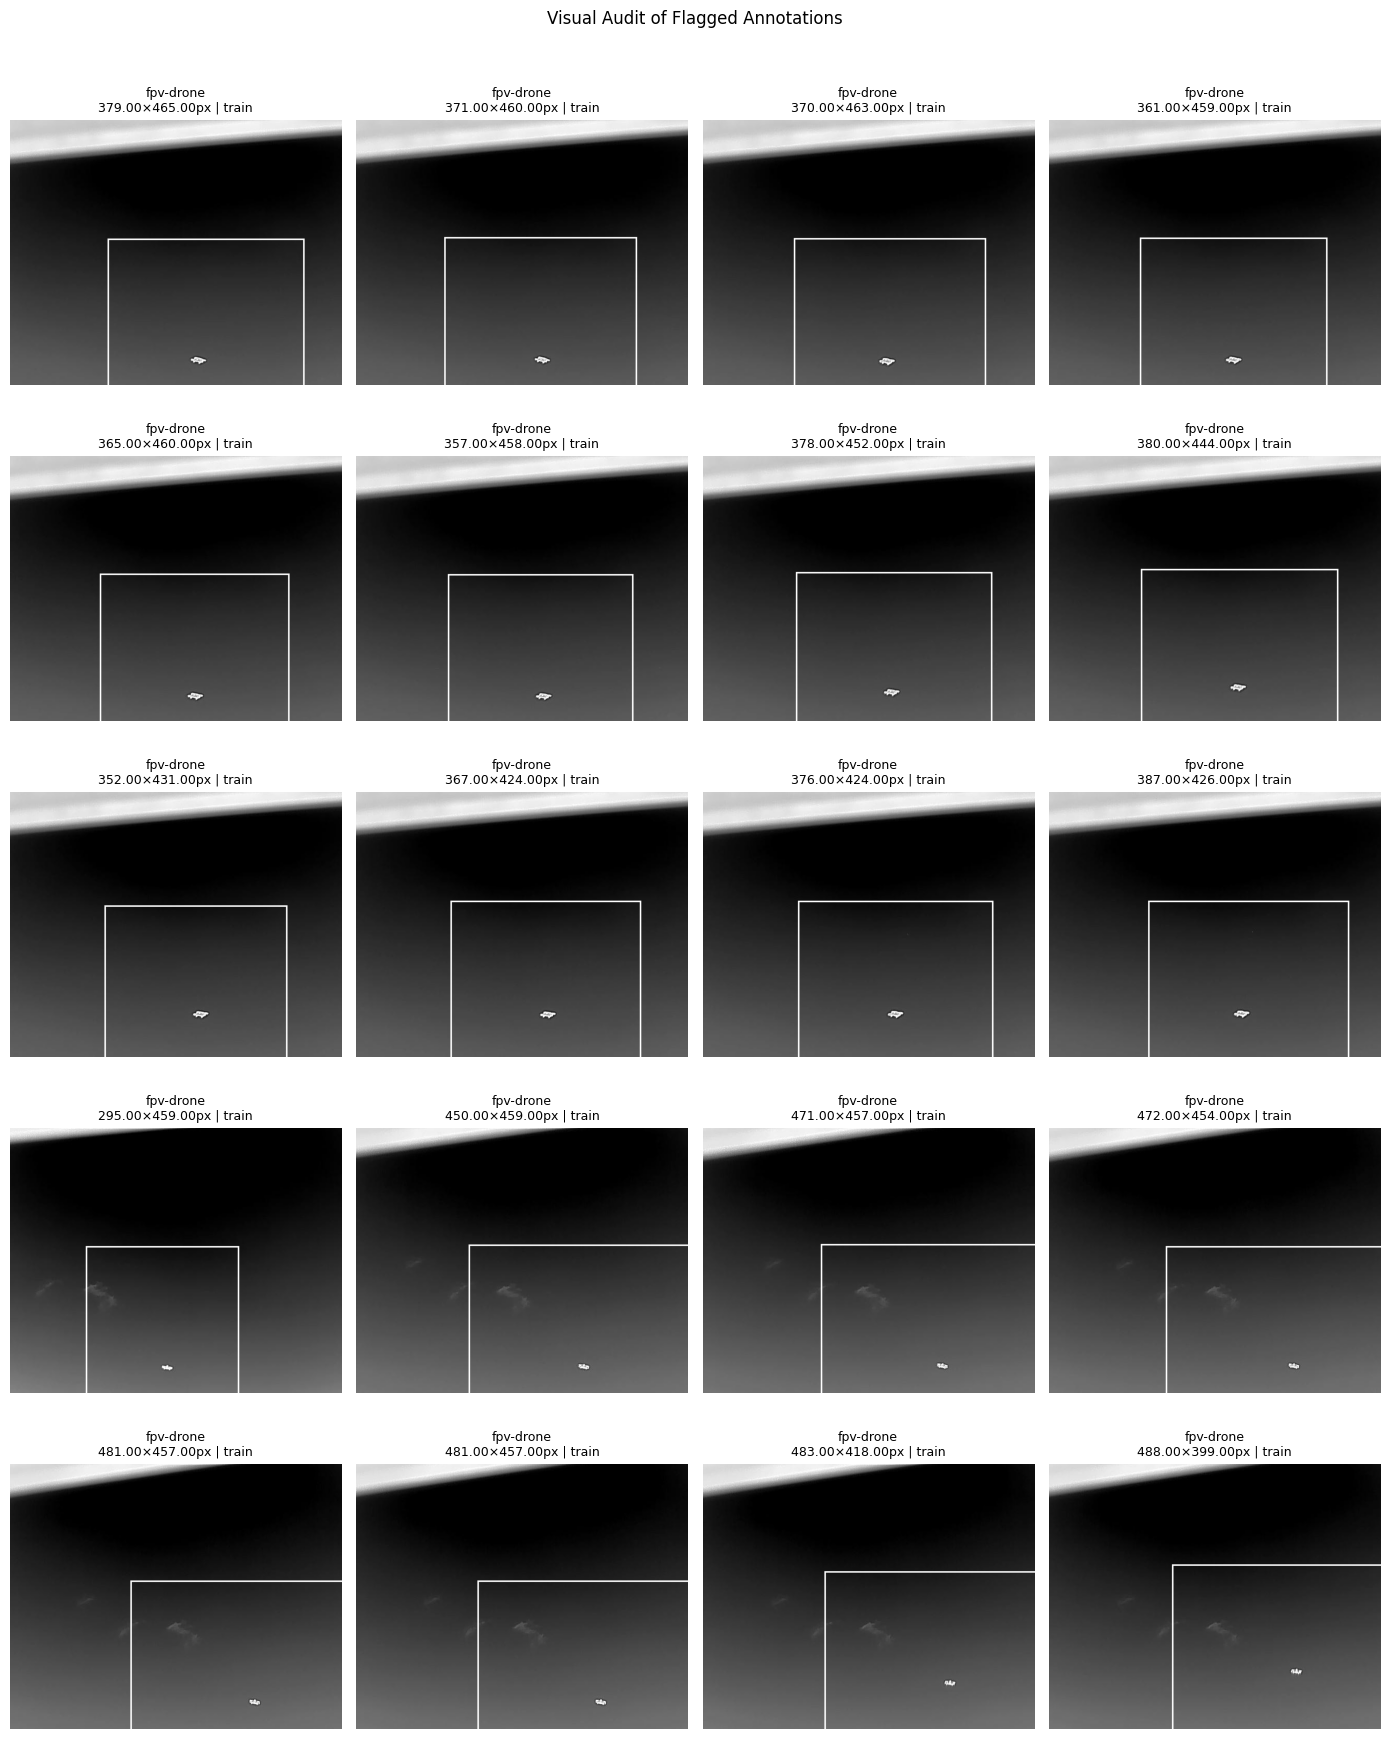

In [28]:
# Visual inspection of every flagged annotation (capped for readability).
problem_indices = audit.index[problem_mask].tolist()[:20]

if not problem_indices:
    print("No problematic annotations were found.")
else:
    n = len(problem_indices)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, problem_indices):
        row = audit.loc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        draw = ImageDraw.Draw(image)
        W, H = image.size

        xc = row["x_center_norm"] * W
        yc = row["y_center_norm"] * H
        bw = row["bbox_width_norm"] * W
        bh = row["bbox_height_norm"] * H

        draw.rectangle(
            [xc-bw/2, yc-bh/2, xc+bw/2, yc+bh/2],
            width=3
        )
        ax.imshow(image)
        ax.set_title(
            f"{row['class_name']}\n"
            f"{bw:.2f}×{bh:.2f}px | {row['split']}",
            fontsize=9
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle("Visual Audit of Flagged Annotations", y=1.01)
    plt.tight_layout()
    plt.show()

### Interpretation

Do not automatically delete every flagged box. First determine whether it is:
1. a genuinely corrupted annotation,
2. a valid object clipped by the image boundary,
3. or an extremely small but legitimate target.

Only clearly invalid annotations should be removed, and the cleaning rule should be documented.

# 20. What Do the Dataset Classes Actually Represent?

The dataset contains six labels, including the ambiguous class `"0"`.

This section investigates whether the labels correspond to meaningful drone categories or mainly to different source datasets / annotation conventions.

We inspect:
- counts,
- target-size statistics,
- filename/source patterns,
- random visual examples from every class.

In [29]:
class_profile = (
    objects_df.groupby(["class_id", "class_name"])
    .agg(
        n_objects=("filename", "size"),
        median_width_px=("bbox_width_px", "median"),
        median_height_px=("bbox_height_px", "median"),
        median_area_px=("bbox_area_px", "median"),
        median_area_fraction=("bbox_area_fraction", "median"),
    )
    .reset_index()
)

display(class_profile)

,class_id,class_name,n_objects,median_width_px,median_height_px,median_area_px,median_area_fraction
0,0,0,3011,14.00,10.00,117.00000,0.000357
1,1,DJI-Phantom,505,83.20,50.02,4234.67320,0.012872
2,2,DRONE,1168,63.00,28.00,1826.00000,0.004834
3,3,drone-thermal,64,23.96,15.35,377.57855,0.001152
4,4,fpv-drone,1334,407.00,226.00,83589.00000,0.255093
5,5,ufo-thermal,28,12.10,9.66,116.32500,0.000355


In [30]:
def source_prefix(filename):
    stem = Path(filename).stem.lower()
    stem = re.sub(r"\.rf\.[a-z0-9]+$", "", stem)
    stem = re.sub(r"_jpg$", "", stem)

    known = [
        "auto", "thermal", "harvest", "image_drone_thermal",
        "dji-phantom", "frame"
    ]
    for prefix in known:
        if stem.startswith(prefix):
            return prefix
    return stem.split("_")[0]

tmp = objects_df.copy()
tmp["source_prefix"] = tmp["filename"].map(source_prefix)

source_by_class = pd.crosstab(
    tmp["class_name"],
    tmp["source_prefix"],
    normalize="index"
)

display(source_by_class.round(3))

source_prefix,000001,000002,000003,000004,000005,000006,000007,000008,000009,000010,...,000220,000222,000223,000229,auto,dji-phantom,frame,harvest,image_drone_thermal,thermal
class_name,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.271,0.0,0.0,0.118,0.000,0.611
DJI-Phantom,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,1.0,0.0,0.000,0.000,0.000
DRONE,0.005,0.003,0.005,0.005,0.003,0.003,0.005,0.005,0.005,0.005,...,0.001,0.003,0.003,0.001,0.000,0.0,0.0,0.000,0.494,0.000
drone-thermal,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,1.0,0.000,0.000,0.000
fpv-drone,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,0.0,1.000,0.000,0.000
ufo-thermal,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.0,1.0,0.000,0.000,0.000


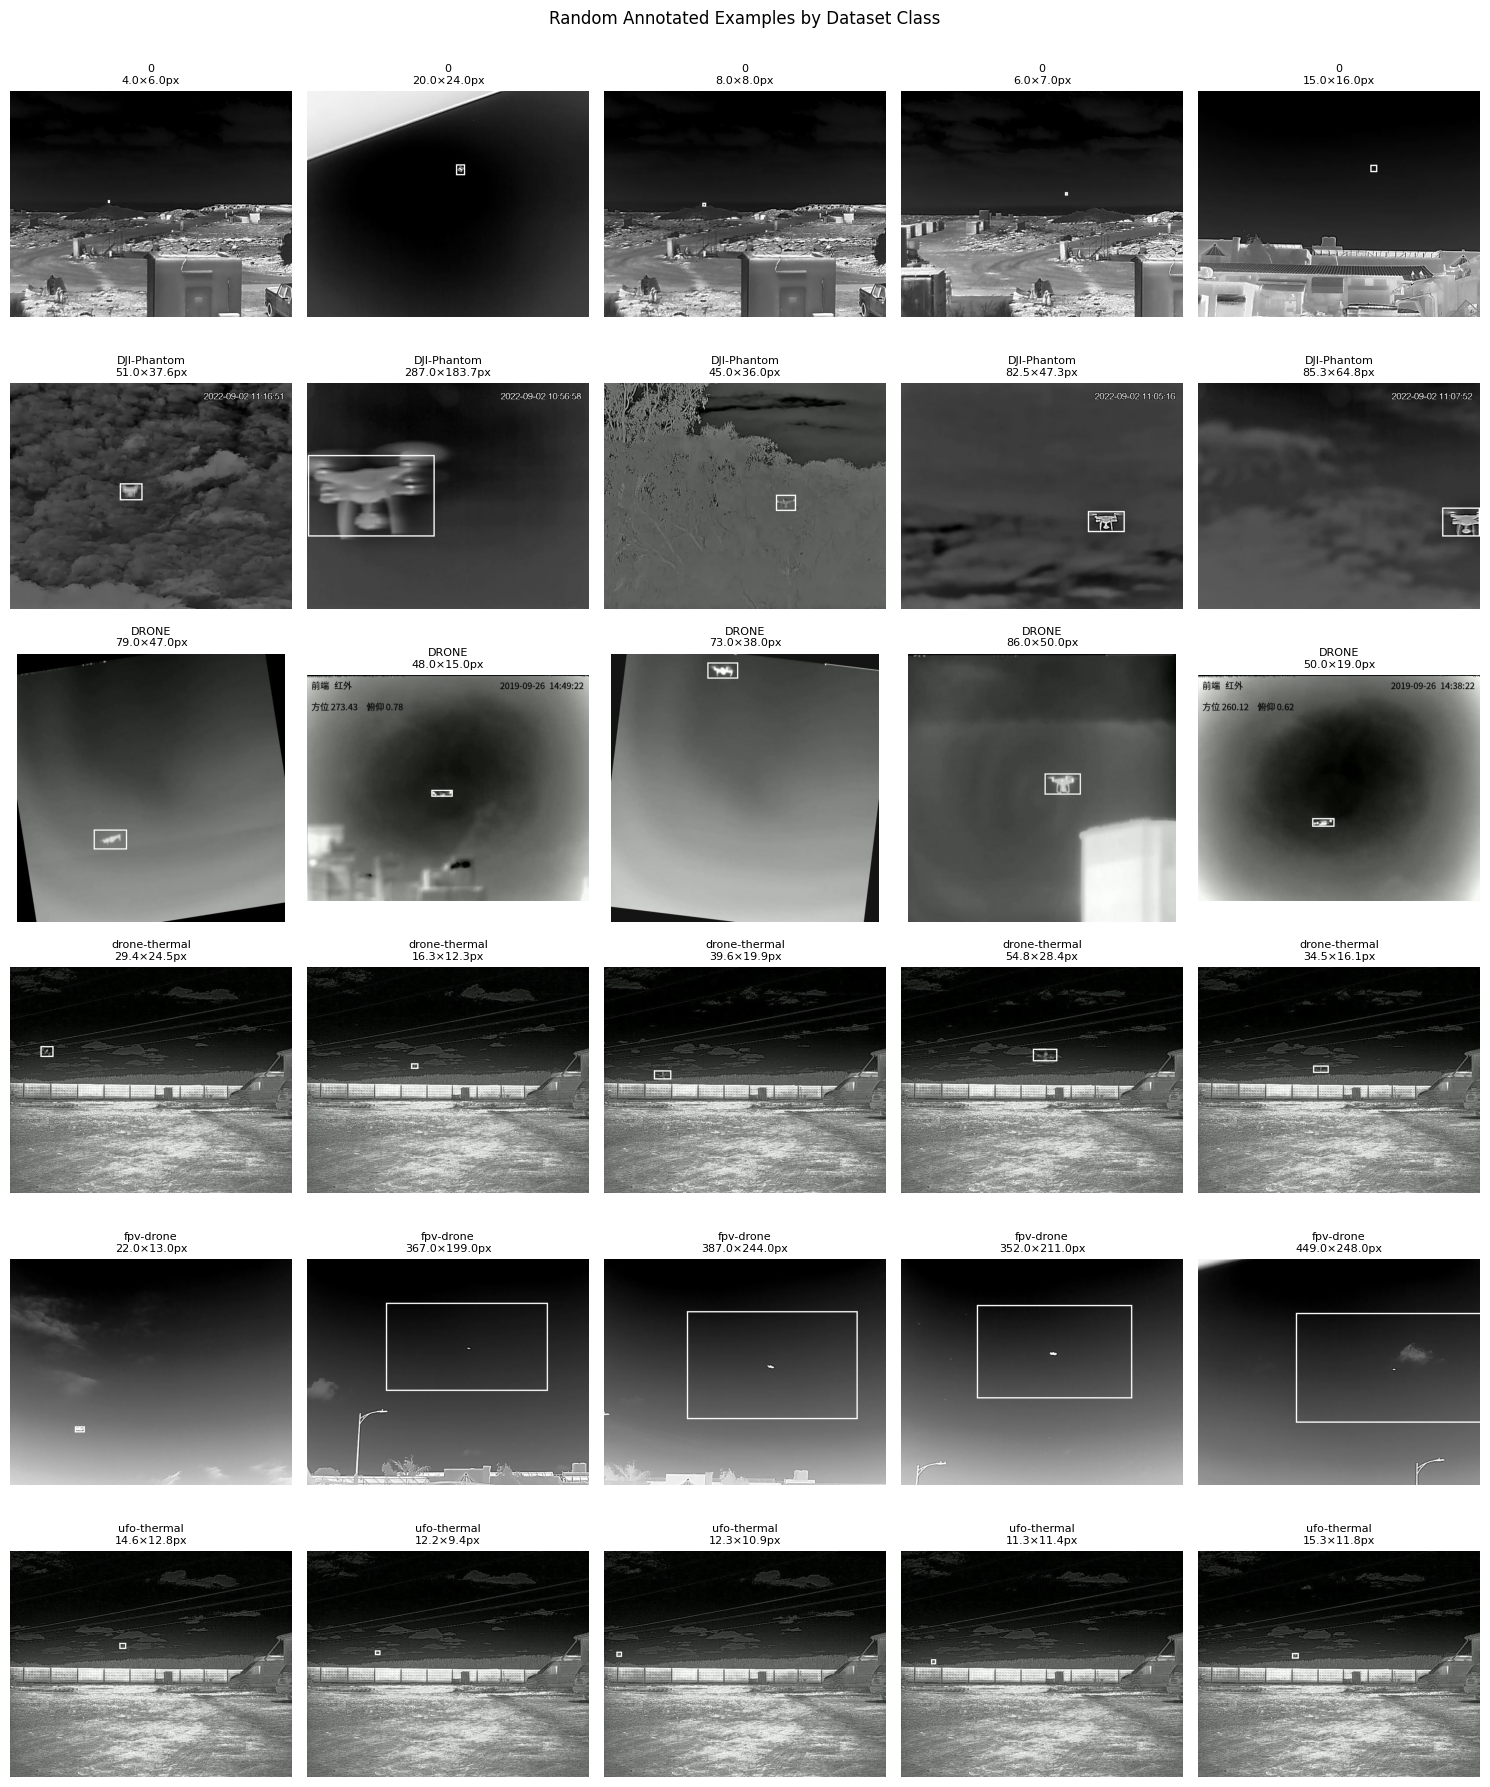

In [31]:
# Random visual examples from each class.
N_PER_CLASS = 5
rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    len(CLASS_NAMES), N_PER_CLASS,
    figsize=(3*N_PER_CLASS, 3*len(CLASS_NAMES))
)

for class_id, class_name in enumerate(CLASS_NAMES):
    group = objects_df[objects_df["class_id"] == class_id]
    n = min(N_PER_CLASS, len(group))
    sampled = group.sample(n=n, random_state=42)

    for col in range(N_PER_CLASS):
        ax = axes[class_id, col]
        ax.axis("off")

        if col >= n:
            continue

        row = sampled.iloc[col]
        image = Image.open(row["image_path"]).convert("RGB")
        draw = ImageDraw.Draw(image)
        W, H = image.size

        xc = row["x_center_norm"] * W
        yc = row["y_center_norm"] * H
        bw = row["bbox_width_norm"] * W
        bh = row["bbox_height_norm"] * H

        draw.rectangle(
            [xc-bw/2, yc-bh/2, xc+bw/2, yc+bh/2],
            width=3
        )

        ax.imshow(image)
        ax.set_title(
            f"{class_name}\n{bw:.1f}×{bh:.1f}px",
            fontsize=8
        )

plt.suptitle("Random Annotated Examples by Dataset Class", y=1.002)
plt.tight_layout()
plt.show()

### Decision to make after visual inspection

If the labels mostly identify **data sources** rather than research-relevant semantic categories, the SR study should not present them as six meaningful drone classes.

For the target-preservation task, it may be more defensible to use a common binary concept such as **thermal aerial target**, while retaining the original class/source as metadata for subgroup analysis.

# 21. Is a Fixed 31×31 Core Appropriate?

The current guidance design uses a 31×31 core inside a 61×61 window.

This section checks that design against the actual target-size distribution **after LR degradation**.

Two separate questions are important:

1. **Coverage:** What fraction of LR bounding boxes fit completely inside each candidate core size?
2. **Dilution:** For tiny targets, what fraction of a fixed core is actually occupied by the target?

A core can have excellent coverage while still containing overwhelmingly background pixels.

In [32]:
# Reuse the SR scale defined earlier in the notebook.
candidate_cores = [5, 9, 15, 31]

scale_analysis = objects_df.copy()
scale_analysis["lr_w"] = scale_analysis["bbox_width_px"] / SCALE_FACTOR
scale_analysis["lr_h"] = scale_analysis["bbox_height_px"] / SCALE_FACTOR
scale_analysis["lr_area"] = scale_analysis["bbox_area_px"] / (SCALE_FACTOR**2)

rows = []
for core in candidate_cores:
    fits = (
        (scale_analysis["lr_w"] <= core) &
        (scale_analysis["lr_h"] <= core)
    )
    occupancy = np.minimum(
        scale_analysis["lr_area"] / (core**2), 1.0
    )

    rows.append({
        "core_size": f"{core}×{core}",
        "target_fits_fraction": fits.mean(),
        "median_core_occupancy": occupancy.median(),
        "p25_core_occupancy": occupancy.quantile(.25),
        "p75_core_occupancy": occupancy.quantile(.75),
    })

core_table = pd.DataFrame(rows)
display(core_table.round(4))

,core_size,target_fits_fraction,median_core_occupancy,p25_core_occupancy,p75_core_occupancy
0,5×5,0.3889,1.0000,0.2750,1.0000
1,9×9,0.4501,0.7330,0.0849,1.0000
2,15×15,0.5725,0.2639,0.0306,1.0000
3,31×31,0.7429,0.0618,0.0072,0.5993


In [33]:
# How much of a 31×31 LR core is occupied by targets in each size regime?
scale_analysis["lr_max_dim"] = scale_analysis[["lr_w", "lr_h"]].max(axis=1)
scale_analysis["size_regime"] = pd.cut(
    scale_analysis["lr_max_dim"],
    bins=[0, 2, 4, 8, 16, np.inf],
    labels=["≤2 px", "2–4 px", "4–8 px", "8–16 px", ">16 px"],
    include_lowest=True
)

scale_analysis["occupancy_31"] = np.minimum(
    scale_analysis["lr_area"] / (31**2), 1.0
)

occupancy_by_size = (
    scale_analysis.groupby("size_regime", observed=True)["occupancy_31"]
    .agg(["count", "median", "mean", "min", "max"])
)

display(occupancy_by_size.round(4))

,count,median,mean,min,max
size_regime,,,,,
≤2 px,1073,0.0023,0.0025,0.0000,0.0042
2–4 px,907,0.0072,0.0086,0.0023,0.0166
4–8 px,751,0.0211,0.0238,0.0091,0.0623
8–16 px,930,0.0860,0.0909,0.0144,0.2331
>16 px,2449,1.0000,0.7224,0.0000,1.0000


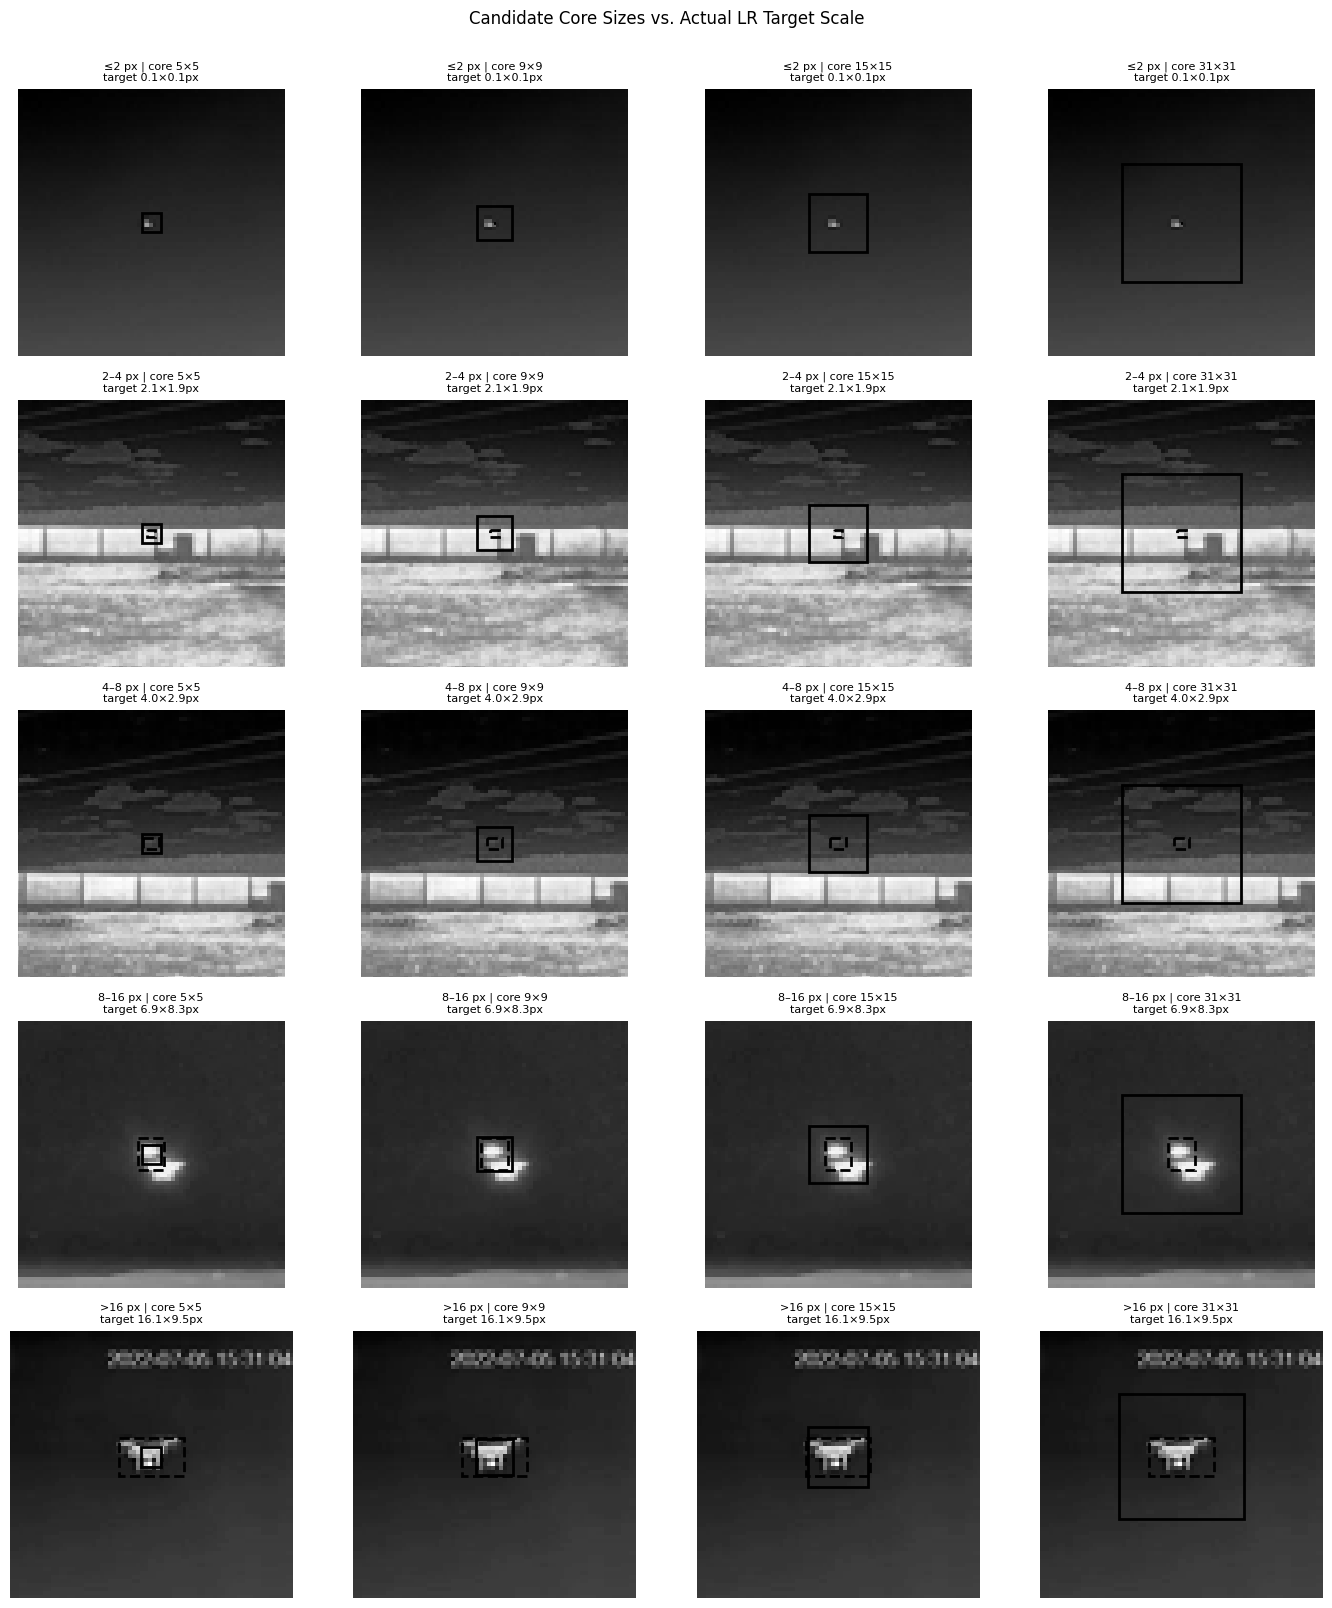

In [34]:
# Visual comparison: the same LR target with several candidate core sizes.
# The square is centered at the ground-truth target center for this diagnostic only.

examples = (
    scale_analysis
    .sort_values("lr_max_dim")
    .groupby("size_regime", observed=True)
    .head(1)
)

fig, axes = plt.subplots(len(examples), len(candidate_cores), figsize=(14, 3.2*len(examples)))
axes = np.atleast_2d(axes)

for r, (_, row) in enumerate(examples.iterrows()):
    hr = Image.open(row["image_path"]).convert("L")
    lr = hr.resize(
        (max(1, hr.width // SCALE_FACTOR), max(1, hr.height // SCALE_FACTOR)),
        Image.Resampling.BICUBIC
    )

    x = row["x_center_norm"] * lr.width
    y = row["y_center_norm"] * lr.height

    for c, core in enumerate(candidate_cores):
        ax = axes[r, c]
        ax.imshow(lr, cmap="gray")

        rect = plt.Rectangle(
            (x-core/2, y-core/2),
            core, core,
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        # Ground-truth LR bbox
        bw = row["lr_w"]
        bh = row["lr_h"]
        gt = plt.Rectangle(
            (x-bw/2, y-bh/2),
            bw, bh,
            fill=False,
            linewidth=2,
            linestyle="--"
        )
        ax.add_patch(gt)

        ax.set_xlim(max(0, x-35), min(lr.width, x+35))
        ax.set_ylim(min(lr.height, y+35), max(0, y-35))
        ax.set_title(
            f"{row['size_regime']} | core {core}×{core}\n"
            f"target {bw:.1f}×{bh:.1f}px",
            fontsize=8
        )
        ax.axis("off")

plt.suptitle("Candidate Core Sizes vs. Actual LR Target Scale", y=1.002)
plt.tight_layout()
plt.show()

### Interpretation

A fixed 31×31 core should not be justified only by a single median HR target size.

If the 31×31 core contains very little target energy for the tiny-target regime, this motivates a later ablation over core sizes or a multi-scale formulation.

This diagnostic does **not** by itself prove that 31×31 is wrong; it identifies whether the design requires empirical validation.

# 22. Does LR Degradation Destroy Target Contrast?

Before blaming the SR model, we should quantify what the LR degradation itself does to the thermal target signal.

For each annotated target, this section measures local peak contrast in:
- the original HR image,
- the bicubic-downsampled LR image.

This tells us whether tiny targets become weaker or disappear already during the observation/degradation stage.

In [35]:
def local_peak_contrast_from_normalized_bbox(img_array, row, ring_scale=2.0):
    H, W = img_array.shape

    xc = row["x_center_norm"] * W
    yc = row["y_center_norm"] * H
    bw = max(row["bbox_width_norm"] * W, 1.0)
    bh = max(row["bbox_height_norm"] * H, 1.0)

    x1 = max(0, int(np.floor(xc - bw/2)))
    x2 = min(W, int(np.ceil(xc + bw/2)))
    y1 = max(0, int(np.floor(yc - bh/2)))
    y2 = min(H, int(np.ceil(yc + bh/2)))

    rx1 = max(0, int(np.floor(xc - ring_scale*bw/2)))
    rx2 = min(W, int(np.ceil(xc + ring_scale*bw/2)))
    ry1 = max(0, int(np.floor(yc - ring_scale*bh/2)))
    ry2 = min(H, int(np.ceil(yc + ring_scale*bh/2)))

    core = img_array[y1:y2, x1:x2]
    outer = img_array[ry1:ry2, rx1:rx2]

    if core.size == 0 or outer.size == 0:
        return np.nan

    mask = np.ones_like(outer, dtype=bool)
    mask[y1-ry1:y2-ry1, x1-rx1:x2-rx1] = False
    ring = outer[mask]

    if ring.size == 0:
        return np.nan

    return float(core.max() - ring.mean())


# Deterministic sample for runtime.
N_CONTRAST = min(2000, len(objects_df))
contrast_sample = objects_df.sample(N_CONTRAST, random_state=42).copy()

records = []
for idx, row in contrast_sample.iterrows():
    hr_pil = Image.open(row["image_path"]).convert("L")
    hr = np.asarray(hr_pil, dtype=np.float32)

    lr_pil = hr_pil.resize(
        (max(1, hr_pil.width // SCALE_FACTOR),
         max(1, hr_pil.height // SCALE_FACTOR)),
        Image.Resampling.BICUBIC
    )
    lr = np.asarray(lr_pil, dtype=np.float32)

    hr_c = local_peak_contrast_from_normalized_bbox(hr, row)
    lr_c = local_peak_contrast_from_normalized_bbox(lr, row)

    records.append({
        "object_index": idx,
        "hr_peak_contrast": hr_c,
        "lr_peak_contrast": lr_c,
    })

contrast_results = pd.DataFrame(records).set_index("object_index")
contrast_analysis = contrast_sample.join(contrast_results)

contrast_analysis["contrast_ratio_lr_hr"] = (
    contrast_analysis["lr_peak_contrast"] /
    (contrast_analysis["hr_peak_contrast"] + 1e-6)
)
contrast_analysis["contrast_change"] = (
    contrast_analysis["lr_peak_contrast"] -
    contrast_analysis["hr_peak_contrast"]
)
contrast_analysis["lr_max_dim"] = contrast_analysis[
    ["bbox_width_px", "bbox_height_px"]
].max(axis=1) / SCALE_FACTOR

display(
    contrast_analysis[
        ["hr_peak_contrast", "lr_peak_contrast",
         "contrast_change", "contrast_ratio_lr_hr", "lr_max_dim"]
    ].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).T
)

,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
hr_peak_contrast,2000.0,155.013748,65.242012,0.302084,51.661902,61.328974,88.066975,178.403114,208.399002,229.729080,243.100918,254.910568
lr_peak_contrast,1995.0,107.911849,79.654683,-5.437500,6.792261,9.919232,19.650000,118.667404,180.774055,206.630365,228.230339,254.888885
contrast_change,1995.0,-47.352563,38.310158,-179.281071,-118.998808,-99.965714,-73.205940,-44.278069,-12.376648,-0.034363,1.050941,46.861526
contrast_ratio_lr_hr,1995.0,0.595006,0.346736,-1.839070,0.088118,0.139842,0.241333,0.698251,0.928682,0.999631,1.006022,1.541614
lr_max_dim,2000.0,30.049866,40.565571,1.000000,1.500000,1.750000,3.500000,12.000000,37.750000,107.000000,118.750000,159.750000


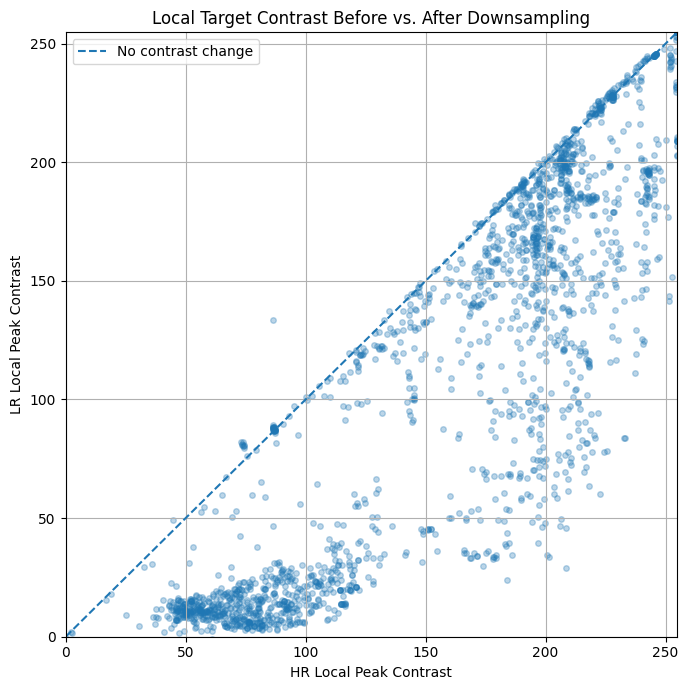

In [36]:
plt.figure(figsize=(7, 7))
plt.scatter(
    contrast_analysis["hr_peak_contrast"],
    contrast_analysis["lr_peak_contrast"],
    alpha=0.3,
    s=16
)

lim = np.nanpercentile(
    np.concatenate([
        contrast_analysis["hr_peak_contrast"].values,
        contrast_analysis["lr_peak_contrast"].values
    ]),
    99
)
plt.plot([0, lim], [0, lim], linestyle="--", label="No contrast change")
plt.xlim(0, lim)
plt.ylim(0, lim)
plt.xlabel("HR Local Peak Contrast")
plt.ylabel("LR Local Peak Contrast")
plt.title("Local Target Contrast Before vs. After Downsampling")
plt.legend()
plt.tight_layout()
plt.show()

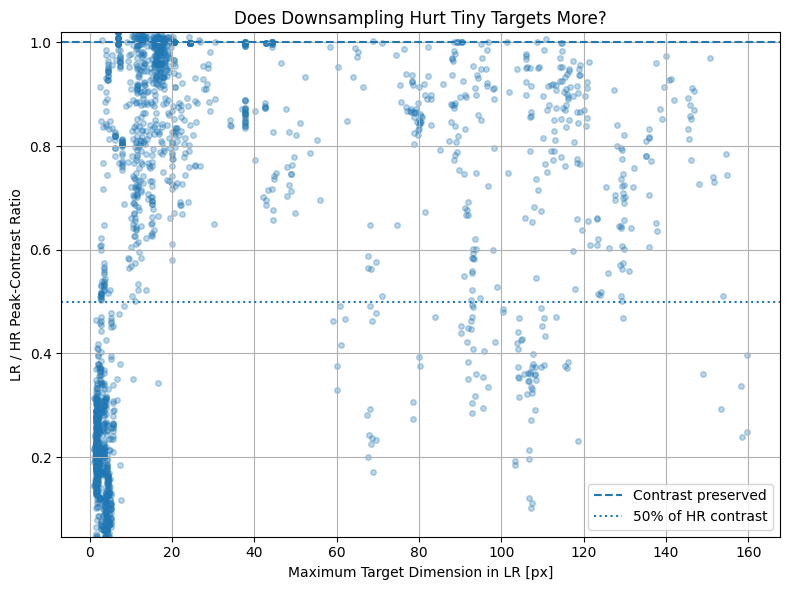

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(
    contrast_analysis["lr_max_dim"],
    contrast_analysis["contrast_ratio_lr_hr"],
    alpha=0.3,
    s=16
)
plt.axhline(1.0, linestyle="--", label="Contrast preserved")
plt.axhline(0.5, linestyle=":", label="50% of HR contrast")
plt.xlabel("Maximum Target Dimension in LR [px]")
plt.ylabel("LR / HR Peak-Contrast Ratio")
plt.title("Does Downsampling Hurt Tiny Targets More?")
plt.ylim(
    np.nanpercentile(contrast_analysis["contrast_ratio_lr_hr"], 1),
    np.nanpercentile(contrast_analysis["contrast_ratio_lr_hr"], 99)
)
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
contrast_analysis["size_regime"] = pd.cut(
    contrast_analysis["lr_max_dim"],
    bins=[0, 2, 4, 8, 16, np.inf],
    labels=["≤2 px", "2–4 px", "4–8 px", "8–16 px", ">16 px"],
    include_lowest=True
)

contrast_by_size = (
    contrast_analysis.groupby("size_regime", observed=True)
    .agg(
        n=("lr_peak_contrast", "count"),
        median_hr_contrast=("hr_peak_contrast", "median"),
        median_lr_contrast=("lr_peak_contrast", "median"),
        median_lr_hr_ratio=("contrast_ratio_lr_hr", "median"),
        fraction_losing_50pct=(
            "contrast_ratio_lr_hr",
            lambda x: (x < 0.5).mean()
        ),
    )
)

display(contrast_by_size.round(3))

,n,median_hr_contrast,median_lr_contrast,median_lr_hr_ratio,fraction_losing_50pct
size_regime,,,,,
≤2 px,358,63.565,13.500,0.214,0.986
2–4 px,274,112.146,26.735,0.222,0.799
4–8 px,244,95.409,27.729,0.242,0.631
8–16 px,306,197.452,157.411,0.904,0.007
>16 px,813,201.029,168.545,0.873,0.123


# 23. DifIISR Failure-Regime Test — Requires Baseline Outputs

The LR analysis above tests the **degradation process**, not DifIISR itself.

To test the stronger hypothesis — *"small, weak targets are preferentially degraded or erased by DifIISR"* — we must compare the LR/HR annotations with actual output images produced by the original DifIISR baseline.

The cell below is intentionally prepared for that experiment. Set `DIFIISR_OUTPUT_DIR` to the folder containing baseline DifIISR outputs with filenames that can be matched to the input images.

In [39]:
# TODO: point this to the ORIGINAL, unguided DifIISR outputs.
DIFIISR_OUTPUT_DIR = Path("/content/difiisr_baseline_outputs")

if not DIFIISR_OUTPUT_DIR.exists():
    print(
        "DifIISR baseline outputs were not found.\n"
        "Run the original DifIISR baseline first, save one SR output per input image, "
        "then set DIFIISR_OUTPUT_DIR and rerun this section."
    )
else:
    print("Baseline output directory found:", DIFIISR_OUTPUT_DIR)
    print(
        "Next step: match SR outputs to annotations and quantify target-preservation "
        "as a function of LR size and LR contrast."
    )

DifIISR baseline outputs were not found.
Run the original DifIISR baseline first, save one SR output per input image, then set DIFIISR_OUTPUT_DIR and rerun this section.


### Required final failure-regime figure

Once baseline outputs are available, the key plot should be:

- **X-axis:** target size in LR,
- **Y-axis:** target contrast/SCR in LR,
- **marker/group:** preserved vs. degraded/lost after original DifIISR.

This is the direct empirical test of the project's central motivation.  
Until baseline outputs are analyzed, we should **not claim** that DifIISR preferentially erases tiny, weak targets.

# 24. Annotation Quality Investigation and Bounding-Box Refinement

The previous EDA revealed a systematic annotation-quality concern: some bounding boxes, particularly in the `fpv-drone` subset, occupy a very large fraction of the image even though visual inspection suggests that the actual thermal target is much smaller.

This section treats that observation as a **data-quality investigation**, not as an assumption that the annotations are wrong.

Workflow:

1. Quantify unusually large annotations.
2. Determine whether the phenomenon is concentrated in particular classes.
3. Visually inspect both extreme and random examples.
4. Generate a **proposed** tight bounding box using a simple thermal-target heuristic.
5. Compare original and proposed annotations visually.
6. Quantify how target-size statistics would change if validated refinements were adopted.

**Important:** Nothing in this section overwrites the original YOLO labels.

,bbox_area_threshold,n_annotations,fraction_of_annotations
0,0.05,1457,0.2385
1,0.10,1269,0.2077
2,0.20,939,0.1537
3,0.30,385,0.0630
4,0.40,191,0.0313
5,0.50,137,0.0224


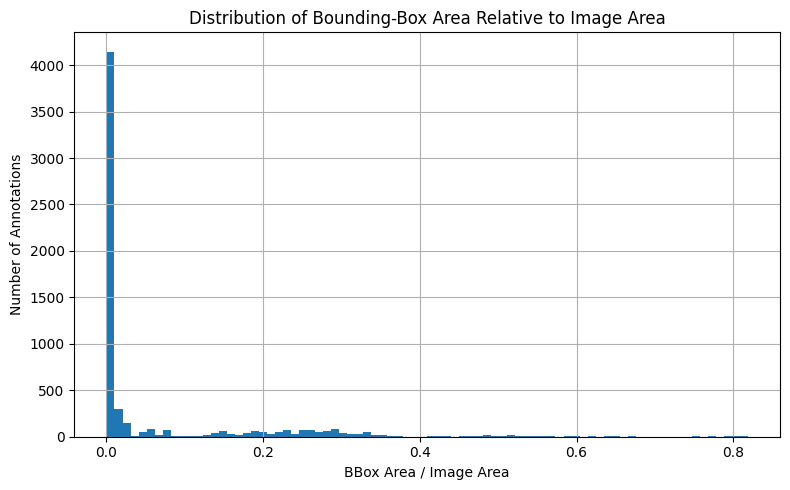

In [40]:
bbox_quality = objects_df.copy()
bbox_quality["bbox_image_ratio"] = bbox_quality["bbox_area_fraction"]

thresholds = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
large_box_summary = []

for threshold in thresholds:
    mask = bbox_quality["bbox_image_ratio"] >= threshold
    large_box_summary.append({
        "bbox_area_threshold": threshold,
        "n_annotations": int(mask.sum()),
        "fraction_of_annotations": float(mask.mean())
    })

large_box_summary = pd.DataFrame(large_box_summary)
display(large_box_summary.round(4))

plt.figure(figsize=(8, 5))
plt.hist(bbox_quality["bbox_image_ratio"], bins=80)
plt.xlabel("BBox Area / Image Area")
plt.ylabel("Number of Annotations")
plt.title("Distribution of Bounding-Box Area Relative to Image Area")
plt.tight_layout()
plt.show()

In [41]:
class_large_box_table = []

for class_name, group in bbox_quality.groupby("class_name"):
    row = {
        "class_name": class_name,
        "n_objects": len(group),
        "median_bbox_image_ratio": group["bbox_image_ratio"].median()
    }
    for threshold in [0.10, 0.20, 0.30, 0.40]:
        row[f"fraction_ge_{int(threshold*100)}pct"] = (
            group["bbox_image_ratio"] >= threshold
        ).mean()
    class_large_box_table.append(row)

class_large_box_table = (
    pd.DataFrame(class_large_box_table)
    .sort_values("median_bbox_image_ratio", ascending=False)
)
display(class_large_box_table.round(4))

,class_name,n_objects,median_bbox_image_ratio,fraction_ge_10pct,fraction_ge_20pct,fraction_ge_30pct,fraction_ge_40pct
4,fpv-drone,1334,0.2551,0.9100,0.6994,0.2886,0.1432
1,DJI-Phantom,505,0.0129,0.1089,0.0119,0.0000,0.0000
2,DRONE,1168,0.0048,0.0000,0.0000,0.0000,0.0000
3,drone-thermal,64,0.0012,0.0000,0.0000,0.0000,0.0000
0,0,3011,0.0004,0.0000,0.0000,0.0000,0.0000
5,ufo-thermal,28,0.0004,0.0000,0.0000,0.0000,0.0000


## 24.1 Visual Evidence: Extreme and Random FPV Examples

To avoid cherry-picking only the most extreme cases, inspect both the largest `fpv-drone` annotations and a random sample.

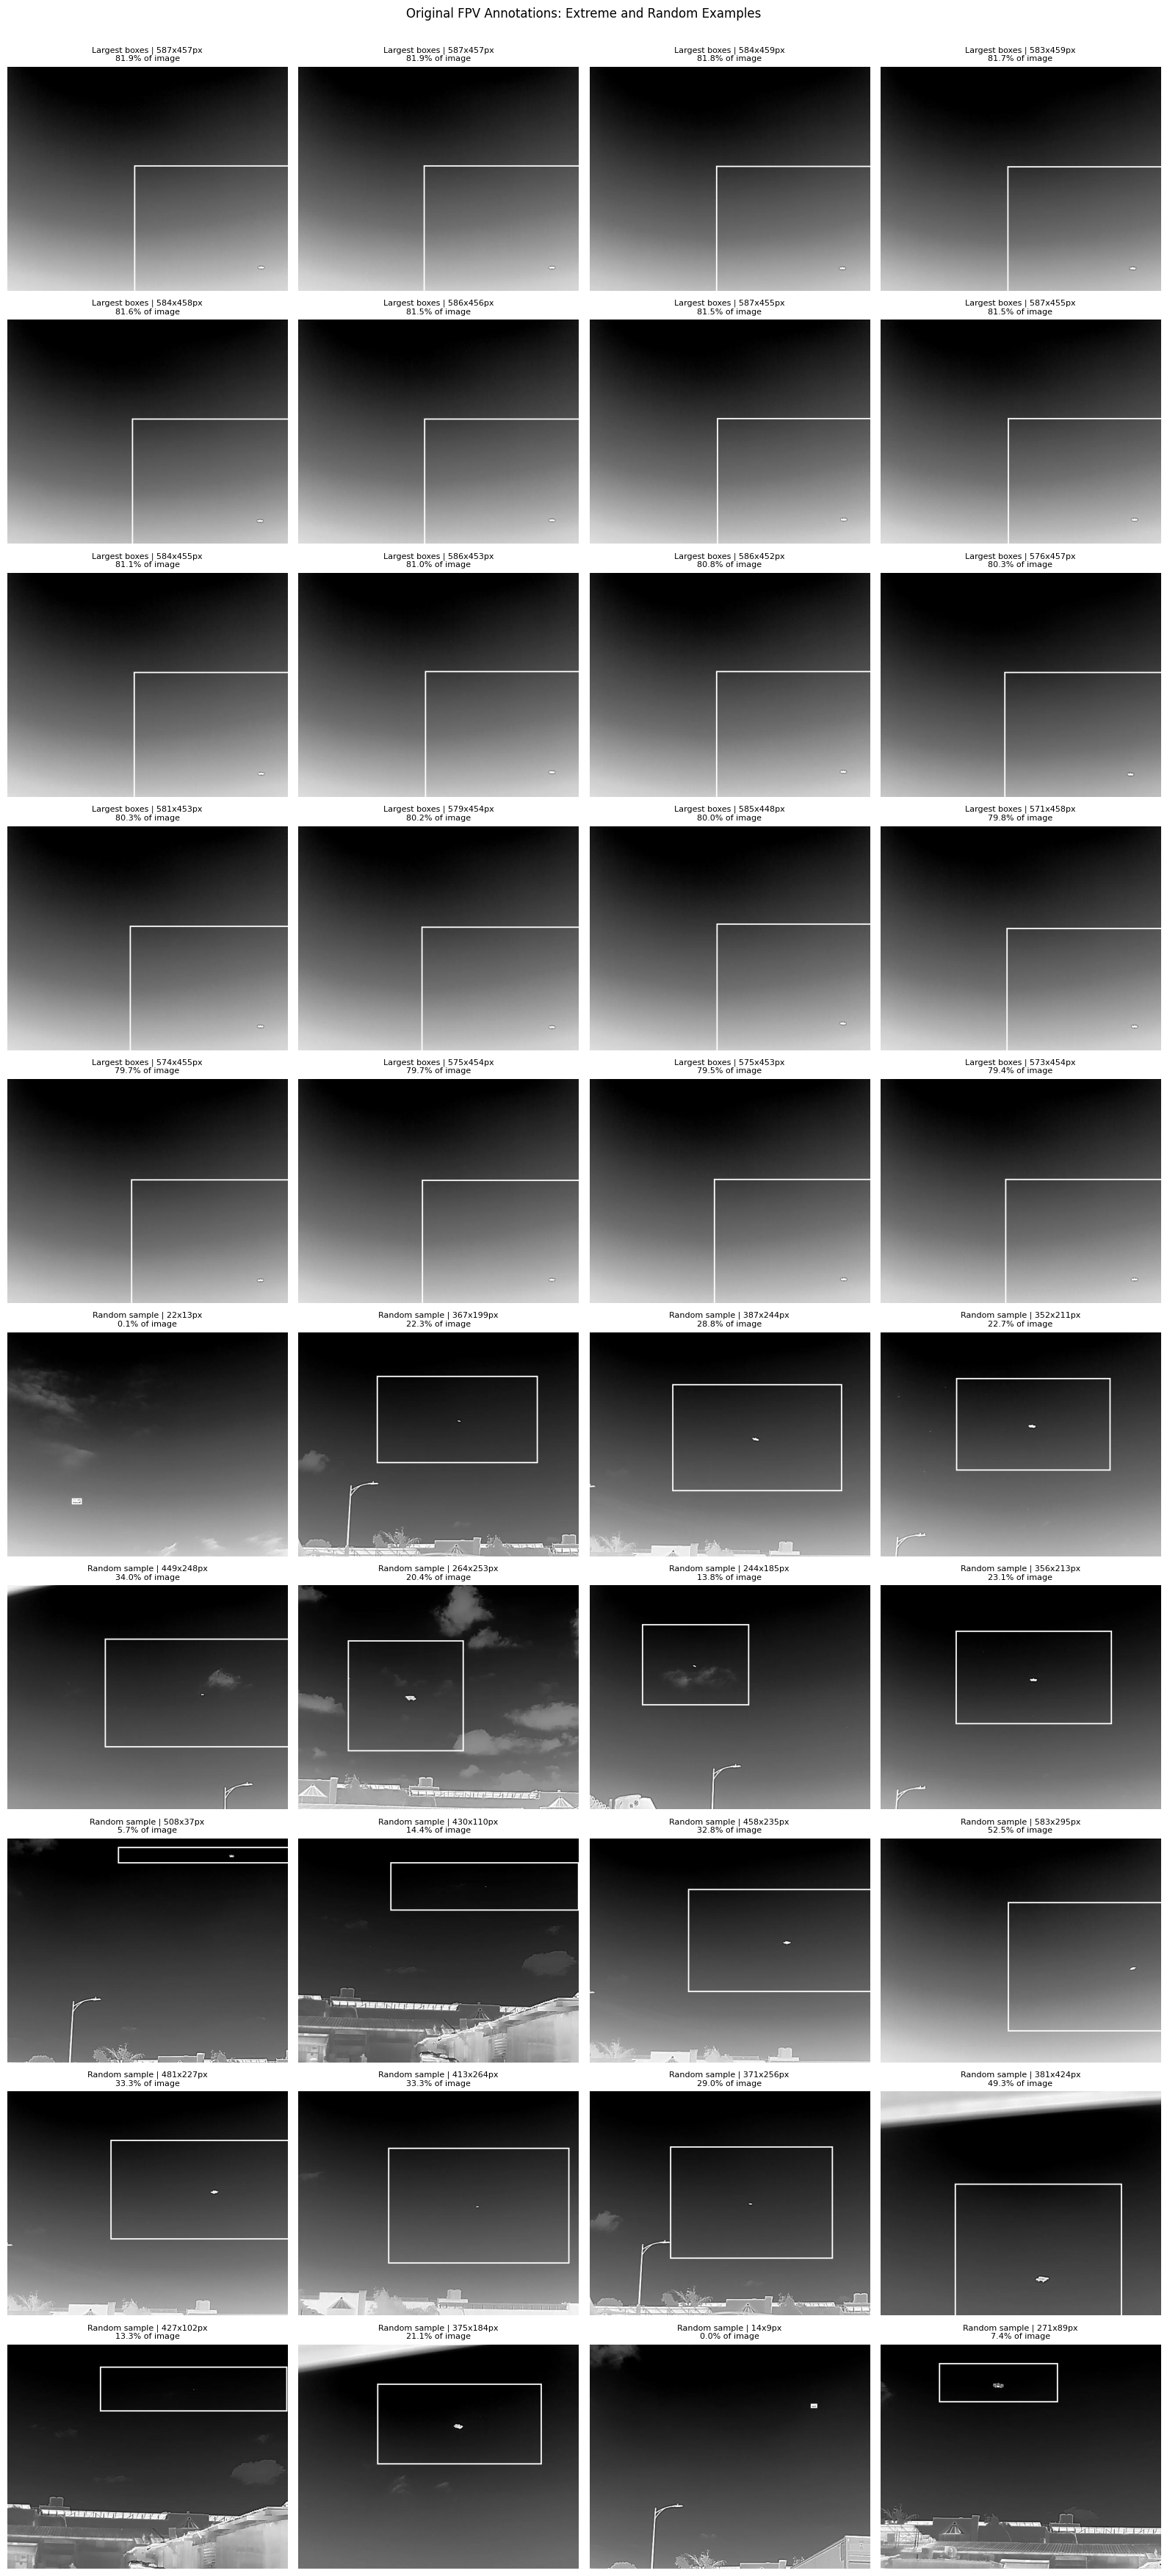

In [42]:
fpv = bbox_quality[bbox_quality["class_name"] == "fpv-drone"].copy()

N_EXTREME = min(20, len(fpv))
N_RANDOM = min(20, len(fpv))

extreme_fpv = fpv.nlargest(N_EXTREME, "bbox_image_ratio")
random_fpv = fpv.sample(N_RANDOM, random_state=42)

inspection_fpv = pd.concat([
    extreme_fpv.assign(sample_type="Largest boxes"),
    random_fpv.assign(sample_type="Random sample")
]).drop_duplicates(subset=["image_path", "object_idx"])

def show_annotation_grid(df, title, ncols=4):
    n = len(df)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (_, row) in zip(axes, df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")
        draw = ImageDraw.Draw(image)
        W, H = image.size
        xc, yc = row["x_center_norm"]*W, row["y_center_norm"]*H
        bw, bh = row["bbox_width_norm"]*W, row["bbox_height_norm"]*H
        draw.rectangle([xc-bw/2, yc-bh/2, xc+bw/2, yc+bh/2], width=3)

        ax.imshow(image)
        ax.set_title(
            f"{row['sample_type']} | {bw:.0f}x{bh:.0f}px\n"
            f"{100*row['bbox_image_ratio']:.1f}% of image",
            fontsize=8
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(title, y=1.002)
    plt.tight_layout()
    plt.show()

show_annotation_grid(
    inspection_fpv,
    "Original FPV Annotations: Extreme and Random Examples"
)

# 25. Proposed Thermal Bounding-Box Refinement

The original annotation is treated as a broad **region of interest (ROI)**.

Inside that ROI, the algorithm:

1. estimates a smooth local background;
2. computes a positive thermal residual;
3. thresholds the strongest residuals;
4. extracts connected components;
5. scores compact bright candidates;
6. selects the strongest plausible component;
7. adds a small safety margin.

This produces a **candidate refinement** only. It does not modify the dataset.

In [43]:
import cv2

def propose_refined_bbox(
    row,
    percentile=99.3,
    blur_sigma=7.0,
    min_component_area=2,
    max_component_fraction=0.08,
    margin_fraction=0.50,
    min_margin_px=2
):
    img = np.asarray(Image.open(row["image_path"]).convert("L"), dtype=np.float32)
    H, W = img.shape

    xc, yc = row["x_center_norm"]*W, row["y_center_norm"]*H
    bw, bh = row["bbox_width_norm"]*W, row["bbox_height_norm"]*H

    ox1 = max(0, int(np.floor(xc-bw/2)))
    oy1 = max(0, int(np.floor(yc-bh/2)))
    ox2 = min(W, int(np.ceil(xc+bw/2)))
    oy2 = min(H, int(np.ceil(yc+bh/2)))

    roi = img[oy1:oy2, ox1:ox2]
    if roi.size == 0 or min(roi.shape) < 3:
        return None

    background = cv2.GaussianBlur(roi, (0, 0), blur_sigma)
    residual = np.maximum(roi-background, 0)

    positive = residual[residual > 0]
    if positive.size == 0:
        return None

    threshold = np.percentile(positive, percentile)
    mask = (residual >= threshold).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, 8)
    roi_area = roi.shape[0] * roi.shape[1]
    candidates = []

    for label_id in range(1, n_labels):
        x, y, w, h, area = stats[label_id]
        if area < min_component_area or area/roi_area > max_component_fraction:
            continue

        values = residual[labels == label_id]
        peak = float(values.max())
        mean_residual = float(values.mean())
        compactness = area / max(w*h, 1)
        score = peak * mean_residual * np.sqrt(area) * (0.5 + compactness)

        candidates.append((score, x, y, w, h, area, peak))

    if not candidates:
        return None

    score, x, y, w, h, area, peak = max(candidates, key=lambda z: z[0])

    mx = max(min_margin_px, int(round(w*margin_fraction)))
    my = max(min_margin_px, int(round(h*margin_fraction)))

    rx1 = max(0, ox1+x-mx)
    ry1 = max(0, oy1+y-my)
    rx2 = min(W, ox1+x+w+mx)
    ry2 = min(H, oy1+y+h+my)

    original_area = max((ox2-ox1)*(oy2-oy1), 1)
    refined_area = max((rx2-rx1)*(ry2-ry1), 1)

    return {
        "original_bbox_px": (ox1, oy1, ox2, oy2),
        "refined_bbox_px": (rx1, ry1, rx2, ry2),
        "refined_width_px": rx2-rx1,
        "refined_height_px": ry2-ry1,
        "refined_area_px": refined_area,
        "area_reduction_ratio": refined_area/original_area,
        "candidate_score": score,
        "candidate_peak_residual": peak,
        "candidate_component_area": area,
        "residual": residual
    }

## 25.1 Generate Candidate Refinements

The first pass is intentionally limited to suspicious `fpv-drone` annotations occupying at least 10% of the image. This threshold is only a screening rule.

In [44]:
SUSPICIOUS_AREA_RATIO = 0.10
fpv_suspicious = fpv[fpv["bbox_image_ratio"] >= SUSPICIOUS_AREA_RATIO].copy()

records = []
for idx, row in fpv_suspicious.iterrows():
    result = propose_refined_bbox(row)
    record = {"object_index": idx, "proposal_available": result is not None}

    if result is not None:
        record.update({
            "refined_width_px": result["refined_width_px"],
            "refined_height_px": result["refined_height_px"],
            "refined_area_px": result["refined_area_px"],
            "area_reduction_ratio": result["area_reduction_ratio"],
            "candidate_score": result["candidate_score"],
            "candidate_peak_residual": result["candidate_peak_residual"],
            "candidate_component_area": result["candidate_component_area"],
            "refined_bbox_px": result["refined_bbox_px"]
        })
    records.append(record)

refinement_df = pd.DataFrame(records).set_index("object_index")
fpv_refinement = fpv_suspicious.join(refinement_df)

print("Suspicious FPV annotations:", len(fpv_suspicious))
print("Candidate refinements:", int(fpv_refinement["proposal_available"].sum()))
print("Proposal rate:", f"{fpv_refinement['proposal_available'].mean():.1%}")

display(fpv_refinement[
    ["filename", "bbox_image_ratio", "bbox_width_px", "bbox_height_px",
     "proposal_available", "refined_width_px", "refined_height_px",
     "area_reduction_ratio"]
].head(20))

Suspicious FPV annotations: 1214
Candidate refinements: 1214
Proposal rate: 100.0%


,filename,bbox_image_ratio,bbox_width_px,bbox_height_px,proposal_available,refined_width_px,refined_height_px,area_reduction_ratio
990,harvest_20260526_134441_255887_jpg.rf.14910f9d...,0.257858,393.0,215.0,True,55,25,0.016157
991,harvest_20260526_143732_541970_jpg.rf.648d9a65...,0.318384,378.0,276.0,True,57,25,0.013659
992,harvest_20260526_143835_762491_jpg.rf.bd00d0ab...,0.537827,379.0,465.0,True,60,25,0.013948
993,harvest_20260526_143835_899122_jpg.rf.97ca8d59...,0.520813,371.0,460.0,True,63,28,0.016580
994,harvest_20260526_143837_016294_jpg.rf.bc4136f5...,0.522797,370.0,463.0,True,60,28,0.015988
995,harvest_20260526_143837_462074_jpg.rf.529ffcce...,0.505673,361.0,459.0,True,60,28,0.016284
996,harvest_20260526_143837_663632_jpg.rf.34d30ea0...,0.512390,365.0,460.0,True,60,28,0.016106
997,harvest_20260526_143838_217895_jpg.rf.8ce91f6e...,0.498981,357.0,458.0,True,64,25,0.015737
998,harvest_20260526_143838_468134_jpg.rf.e645d355...,0.521411,378.0,452.0,True,60,28,0.015432
999,harvest_20260526_143838_582565_jpg.rf.ab70c00e...,0.514893,380.0,444.0,True,65,28,0.016291


# 26. Visual Validation of Proposed Refinements

Each row shows:

**Original annotation → thermal residual → proposed refined annotation**

This visual QA is required before any corrected label files are created.

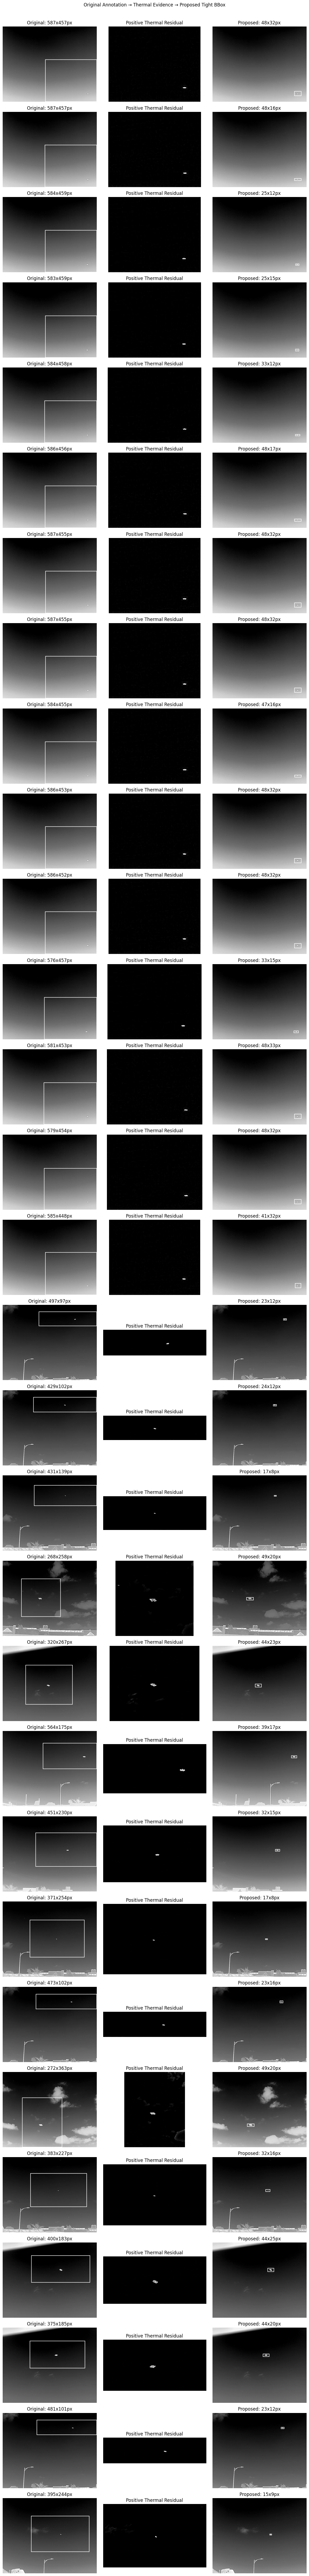

In [45]:
available = fpv_refinement[fpv_refinement["proposal_available"]].copy()

extreme_ids = available.nlargest(min(15, len(available)), "bbox_image_ratio").index.tolist()
remaining = available.drop(index=extreme_ids, errors="ignore")
random_ids = remaining.sample(min(15, len(remaining)), random_state=42).index.tolist()
qa_ids = extreme_ids + random_ids

fig, axes = plt.subplots(len(qa_ids), 3, figsize=(12, 3.2*len(qa_ids)))
axes = np.atleast_2d(axes)

for r, idx in enumerate(qa_ids):
    row = fpv_refinement.loc[idx]
    result = propose_refined_bbox(row)

    image = Image.open(row["image_path"]).convert("RGB")
    original = image.copy()
    refined = image.copy()

    ImageDraw.Draw(original).rectangle(result["original_bbox_px"], width=3)
    ImageDraw.Draw(refined).rectangle(result["refined_bbox_px"], width=3)

    axes[r,0].imshow(original)
    axes[r,0].set_title(f"Original: {row['bbox_width_px']:.0f}x{row['bbox_height_px']:.0f}px")
    axes[r,1].imshow(result["residual"], cmap="gray")
    axes[r,1].set_title("Positive Thermal Residual")
    axes[r,2].imshow(refined)
    axes[r,2].set_title(
        f"Proposed: {result['refined_width_px']}x{result['refined_height_px']}px"
    )

    for ax in axes[r]:
        ax.axis("off")

plt.suptitle("Original Annotation → Thermal Evidence → Proposed Tight BBox", y=1.002)
plt.tight_layout()
plt.show()

In [46]:
# The most aggressive proposed changes deserve separate attention.
aggressive = available.sort_values("area_reduction_ratio").head(25)

display(aggressive[
    ["filename", "bbox_width_px", "bbox_height_px",
     "refined_width_px", "refined_height_px",
     "area_reduction_ratio", "candidate_peak_residual"]
])

,filename,bbox_width_px,bbox_height_px,refined_width_px,refined_height_px,area_reduction_ratio,candidate_peak_residual
3346,harvest_20260526_151252_655307_jpg.rf.a8d9d99f...,417.0,260.0,8,6,0.000442,111.121857
5152,harvest_20260526_151254_448470_jpg.rf.1f42e619...,417.0,221.0,7,6,0.000453,118.695549
1206,harvest_20260526_151253_170929_jpg.rf.65e68677...,417.0,244.0,8,6,0.000471,109.841034
5150,harvest_20260526_151253_354448_jpg.rf.3a49c05a...,416.0,243.0,8,6,0.000473,115.181007
1198,harvest_20260526_151227_440367_jpg.rf.1b98e49d...,430.0,408.0,9,7,0.000474,106.185287
3344,harvest_20260526_151252_291283_jpg.rf.a3499035...,425.0,271.0,8,7,0.000483,102.923096
5151,harvest_20260526_151253_784290_jpg.rf.3054d4c1...,416.0,233.0,8,6,0.000493,123.020111
3347,harvest_20260526_151253_846455_jpg.rf.4700d148...,417.0,232.0,8,6,0.000495,107.063477
1207,harvest_20260526_151253_916764_jpg.rf.37c9b88e...,417.0,230.0,8,6,0.000499,122.458344
1209,harvest_20260526_151254_111504_jpg.rf.f0e35388...,417.0,224.0,8,6,0.000513,140.487885


# 27. Before-vs-After Size Analysis — Provisional

This is a **counterfactual analysis**: what would the size distribution look like if all currently proposed FPV refinements were accepted?

The result is provisional until visual validation is complete.

In [47]:
provisional = objects_df.copy()
provisional["analysis_width_px"] = provisional["bbox_width_px"]
provisional["analysis_height_px"] = provisional["bbox_height_px"]
provisional["analysis_area_px"] = provisional["bbox_area_px"]
provisional["was_provisionally_refined"] = False

for idx, row in available.iterrows():
    provisional.loc[idx, "analysis_width_px"] = row["refined_width_px"]
    provisional.loc[idx, "analysis_height_px"] = row["refined_height_px"]
    provisional.loc[idx, "analysis_area_px"] = row["refined_area_px"]
    provisional.loc[idx, "was_provisionally_refined"] = True

before_after = pd.DataFrame({
    "Original annotations": [
        objects_df["bbox_width_px"].median(),
        objects_df["bbox_height_px"].median(),
        objects_df["bbox_area_px"].median(),
        objects_df["bbox_area_px"].quantile(.90),
        objects_df["bbox_area_px"].quantile(.95)
    ],
    "Provisional refined annotations": [
        provisional["analysis_width_px"].median(),
        provisional["analysis_height_px"].median(),
        provisional["analysis_area_px"].median(),
        provisional["analysis_area_px"].quantile(.90),
        provisional["analysis_area_px"].quantile(.95)
    ]
}, index=[
    "Median width [px]", "Median height [px]", "Median area [px^2]",
    "90th percentile area [px^2]", "95th percentile area [px^2]"
])

display(before_after.round(2))

,Original annotations,Provisional refined annotations
Median width [px],48.00,29.00
Median height [px],23.00,16.00
Median area [px^2],950.00,494.50
90th percentile area [px^2],86443.00,4951.80
95th percentile area [px^2],105887.35,9849.34


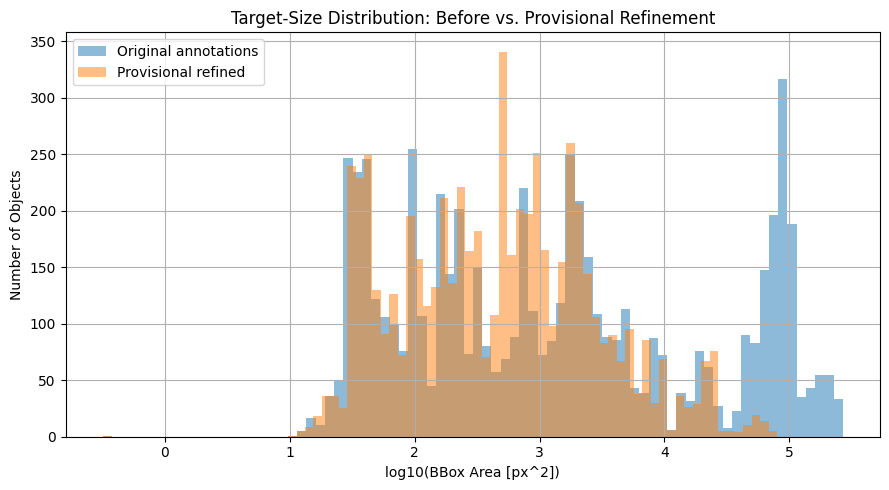

In [48]:
original_area = objects_df.loc[objects_df["bbox_area_px"] > 0, "bbox_area_px"]
refined_area = provisional.loc[provisional["analysis_area_px"] > 0, "analysis_area_px"]

plt.figure(figsize=(9,5))
plt.hist(np.log10(original_area), bins=80, alpha=0.5, label="Original annotations")
plt.hist(np.log10(refined_area), bins=80, alpha=0.5, label="Provisional refined")
plt.xlabel("log10(BBox Area [px^2])")
plt.ylabel("Number of Objects")
plt.title("Target-Size Distribution: Before vs. Provisional Refinement")
plt.legend()
plt.tight_layout()
plt.show()

,Original,Provisional refined,Original fraction,Provisional refined fraction
<=2 px,1073,1086,0.1756,0.1777
2-4 px,907,989,0.1484,0.1619
4-8 px,751,1318,0.1229,0.2157
8-16 px,930,1449,0.1522,0.2372
>16 px,2449,1268,0.4008,0.2075


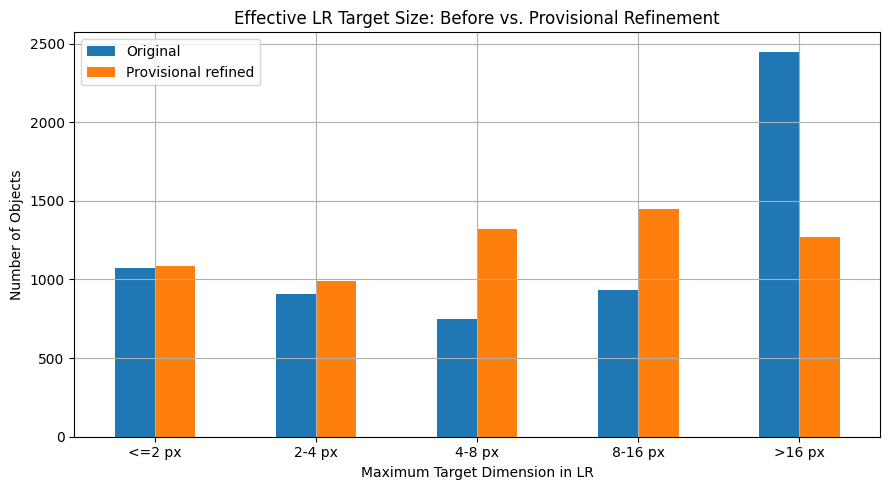

In [49]:
original_lr_max = (
    objects_df[["bbox_width_px","bbox_height_px"]].max(axis=1) / SCALE_FACTOR
)
refined_lr_max = (
    provisional[["analysis_width_px","analysis_height_px"]].max(axis=1) / SCALE_FACTOR
)

bins = [0,2,4,8,16,np.inf]
labels = ["<=2 px","2-4 px","4-8 px","8-16 px",">16 px"]

original_regime = pd.cut(original_lr_max, bins=bins, labels=labels, include_lowest=True)
refined_regime = pd.cut(refined_lr_max, bins=bins, labels=labels, include_lowest=True)

lr_comparison = pd.DataFrame({
    "Original": original_regime.value_counts(sort=False),
    "Provisional refined": refined_regime.value_counts(sort=False)
})
lr_comparison["Original fraction"] = lr_comparison["Original"] / len(objects_df)
lr_comparison["Provisional refined fraction"] = (
    lr_comparison["Provisional refined"] / len(provisional)
)

display(lr_comparison.round(4))

lr_comparison[["Original","Provisional refined"]].plot(kind="bar", figsize=(9,5))
plt.xlabel("Maximum Target Dimension in LR")
plt.ylabel("Number of Objects")
plt.title("Effective LR Target Size: Before vs. Provisional Refinement")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 28. Decision Gate

Do **not** export corrected YOLO labels yet.

First review the visual QA and determine:

- Does the proposed box consistently surround the actual drone?
- Does it select hot pixels, clouds, borders, or unrelated structures?
- Is the safety margin sufficient?
- Are failures associated with particular image sources?
- Are some original large boxes actually correct?

If the candidate procedure is reliable, the next stage will create an auditable correction pipeline containing:

- an acceptance criterion and confidence score;
- a CSV with original and corrected coordinates;
- a separate `corrected_labels/` directory;
- a complete rerun of the EDA using only approved corrections.

The original labels will remain unchanged.